### imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
from dotenv import load_dotenv
import os

In [2]:
load_dotenv()
api_key = os.getenv("apikey")

In [ ]:
def player_stats(link):
    player_api_url = f"https://api.sportdb.dev{link}"
    response = requests.get(player_api_url,headers=({"X-API-Key":api_key}), verify=False)

    player = response.json()
    player

    stat_count = 0
    rows = []

    for competition in player['careers']:
        for season_data in player['careers']['league']:
            print(season_data['season'], competition, season_data['teamSlug'])
            print(10*'=')
            stat_count += 1 
            stats = {stat['name']: stat['value'] for stat in season_data['stats']}
            print(stats)
            row = [
                stats.get("Player rating", 0),
                stats.get("Matches Played", 0),
                stats.get("Goals Scored", 0),
                stats.get("Assists", 0),
                stats.get("Yellow Cards"),
                stats.get('Red Cards'),
                season_data.get('season')
            ]
            rows.append(row)
            print()

    player_stats = pd.DataFrame(
        rows,
        columns= [
            'Player rating', 
            'Matches Played', 
            'Goals Scored',
            'Assists', 
            'Yellow Cards', 
            'Red Cards',
            'Season'
        ]
    )
        
    clean_stats = player_stats.sort_values(by='Season').drop_duplicates()

    # AT - all time player stats - across all leagues and competitions
    AT_player_stats = clean_stats.sum()
    AT_matches = AT_player_stats['Matches Played']
    AT_player_rating = clean_stats[clean_stats['Player rating']>0]['Player rating'].mean()
    if AT_matches > 0:
        AT_goals_scored_avg = clean_stats['Goals Scored'].sum()/AT_matches
        AT_assists_avg = clean_stats['Assists'].sum()/AT_matches
        AT_yellows_avg = clean_stats['Yellow Cards'].sum()/AT_matches
        AT_reds_avg = clean_stats['Red Cards'].sum()/AT_matches
    else:
        AT_goals_scored_avg = 0
        AT_assists_avg = 0
        AT_yellows_avg = 0
        AT_reds_avg = 0

    print(f"All time {player['firstName']} {player['lastName']} Statistics")
    print(f"Matches: {AT_player_stats['Matches Played']}")
    print(f"Goals: {AT_player_stats['Goals Scored']}")
    print(f"Assists: {AT_player_stats['Assists']}")
    print(f"Yellows: {AT_player_stats['Yellow Cards']}")
    print(f"Reds: {AT_player_stats['Red Cards']}")
    print("==== Averages =====")
    print(f"Average Player Rating: {AT_player_rating}")
    print(f"Goals Scored per match: {AT_goals_scored_avg}")
    print(f"Assists per match: {AT_assists_avg}")
    print(f"Yellow Cards per match: {AT_yellows_avg}")
    print(f"Red Cards per match: {AT_reds_avg}")

    season = clean_stats['Season']
    matches = clean_stats['Matches Played']
    goals = clean_stats['Goals Scored']
    assists = clean_stats['Assists']
    yellows = clean_stats['Yellow Cards']
    reds = clean_stats['Red Cards']

    stats = [matches, goals, assists, yellows, reds]

    for stat in stats:    
        plt.figure(figsize=(8,5))
        plt.plot(season,stat)
        plt.title(f"{player['firstName']} {player['lastName']} - {stat.name} through seasons")

In [37]:
team_api_url = "https://api.sportdb.dev/api/flashscore/team/rakow-czestochowa/SQOrbYim"
response = requests.get(team_api_url,headers=({"X-API-Key":api_key}),verify=False)


c:\app\Python311\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.sportdb.dev'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [38]:
team=response.json()
squad = team['squad'][0]['players']

/api/flashscore/player/trelowski-kacper/hpCg1pJH


c:\app\Python311\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.sportdb.dev'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


2025-2026 league rakow-czestochowa
{'Player rating': 6.5, 'Matches Played': 11, 'Save Percentage': 58.3, 'Shutouts': 3, 'Yellow Cards': 0, 'Red Cards': 0}

2024-2025 league rakow-czestochowa
{'Player rating': 6.8, 'Matches Played': 34, 'Save Percentage': 78.7, 'Shutouts': 17, 'Yellow Cards': 1, 'Red Cards': 0}

2023-2024 league slask-wroclaw
{'Player rating': 6.7, 'Matches Played': 1, 'Save Percentage': 57.1, 'Shutouts': 0, 'Yellow Cards': 0, 'Red Cards': 0}

2022-2023 league rakow-czestochowa
{'Player rating': 6.5, 'Matches Played': 6, 'Save Percentage': 56.3, 'Shutouts': 1, 'Yellow Cards': 0, 'Red Cards': 0}

2021-2022 league rakow-czestochowa
{'Player rating': 6.9, 'Matches Played': 7, 'Save Percentage': 73.9, 'Shutouts': 3, 'Yellow Cards': 0, 'Red Cards': 0}

2020-2021 league sokol-ostroda
{'Player rating': 0, 'Matches Played': 11, 'Save Percentage': None, 'Shutouts': None, 'Yellow Cards': 0, 'Red Cards': 0}

2025-2026 nationalCups rakow-czestochowa
{'Player rating': 6.5, 'Matches 

c:\app\Python311\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.sportdb.dev'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


2025-2026 league rakow-czestochowa
{'Player rating': 6.5, 'Matches Played': 7, 'Save Percentage': 66.7, 'Shutouts': 1, 'Yellow Cards': 0, 'Red Cards': 0}

2024-2025 league aston-villa
{'Player rating': 0, 'Matches Played': 2, 'Save Percentage': 53.9, 'Shutouts': 0, 'Yellow Cards': 0, 'Red Cards': 0}

2023-2024 league puszcza
{'Player rating': 6.9, 'Matches Played': 26, 'Save Percentage': 73.7, 'Shutouts': 7, 'Yellow Cards': 3, 'Red Cards': 0}

2023-2024 league aston-villa
{'Player rating': 0, 'Matches Played': 2, 'Save Percentage': 46.2, 'Shutouts': 0, 'Yellow Cards': 1, 'Red Cards': 0}

2022-2023 league aston-villa
{'Player rating': 0, 'Matches Played': 11, 'Save Percentage': 56.8, 'Shutouts': 3, 'Yellow Cards': 0, 'Red Cards': 0}

2021-2022 league aston-villa
{'Player rating': 0, 'Matches Played': 10, 'Save Percentage': 62.7, 'Shutouts': 0, 'Yellow Cards': 0, 'Red Cards': 0}

2021-2022 league aston-villa
{'Player rating': 0, 'Matches Played': 9, 'Save Percentage': None, 'Shutouts': N

...

2025-2026 league rakow-czestochowa
{'Player rating': 6.3, 'Matches Played': 12, 'Goals Scored': 0, 'Assists': 0, 'Yellow Cards': 3, 'Red Cards': 0}

2024-2025 league 1-fc-koln
{'Player rating': 6.5, 'Matches Played': 9, 'Goals Scored': 1, 'Assists': 0, 'Yellow Cards': 0, 'Red Cards': 0}

2024-2025 league widzew-lodz
{'Player rating': 7.2, 'Matches Played': 18, 'Goals Scored': 9, 'Assists': 2, 'Yellow Cards': 2, 'Red Cards': 0}

2023-2024 league widzew-lodz
{'Player rating': 6.7, 'Matches Played': 32, 'Goals Scored': 5, 'Assists': 3, 'Yellow Cards': 2, 'Red Cards': 0}

2022-2023 league liberec
{'Player rating': 6.5, 'Matches Played': 28, 'Goals Scored': 4, 'Assists': 2, 'Yellow Cards': 2, 'Red Cards': 0}

2021-2022 league liberec
{'Player rating': 0, 'Matches Played': 30, 'Goals Scored': 4, 'Assists': 0, 'Yellow Cards': 3, 'Red Cards': 0}

2020-2021 league liberec
{'Player rating': 0, 'Matches Played': 1, 'Goals Scored': 2, 'Assists': None, 'Yellow Cards': 0, 'Red Cards': 0}

2020-2021 

c:\app\Python311\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.sportdb.dev'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


2025-2026 league rakow-czestochowa
{'Player rating': 6.5, 'Matches Played': 6, 'Goals Scored': 0, 'Assists': 1, 'Yellow Cards': 1, 'Red Cards': 0}

2024-2025 league rakow-czestochowa
{'Player rating': 0, 'Matches Played': 1, 'Goals Scored': 0, 'Assists': 0, 'Yellow Cards': 0, 'Red Cards': 0}

2024-2025 league us-goree
{'Player rating': 0, 'Matches Played': 3, 'Goals Scored': 4, 'Assists': None, 'Yellow Cards': 0, 'Red Cards': 0}

2022-2023 league us-goree
{'Player rating': 0, 'Matches Played': 5, 'Goals Scored': 5, 'Assists': None, 'Yellow Cards': 0, 'Red Cards': 0}

2025-2026 nationalCups rakow-czestochowa
{'Player rating': 6.5, 'Matches Played': 6, 'Goals Scored': 0, 'Assists': 1, 'Yellow Cards': 1, 'Red Cards': 0}

2024-2025 nationalCups rakow-czestochowa
{'Player rating': 0, 'Matches Played': 1, 'Goals Scored': 0, 'Assists': 0, 'Yellow Cards': 0, 'Red Cards': 0}

2024-2025 nationalCups us-goree
{'Player rating': 0, 'Matches Played': 3, 'Goals Scored': 4, 'Assists': None, 'Yellow Ca

c:\app\Python311\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.sportdb.dev'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


ZeroDivisionError: division by zero

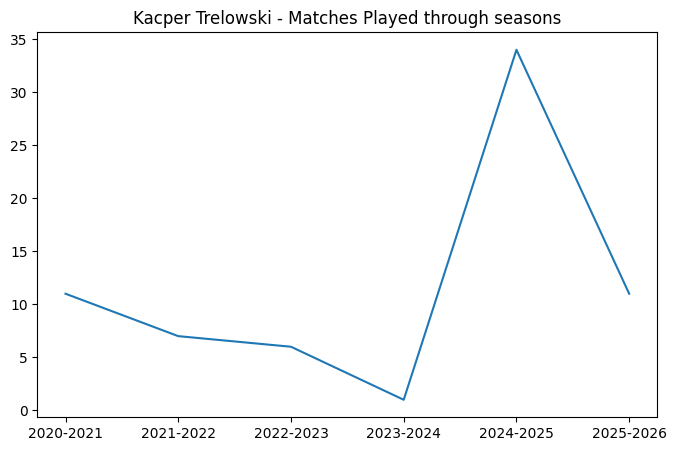

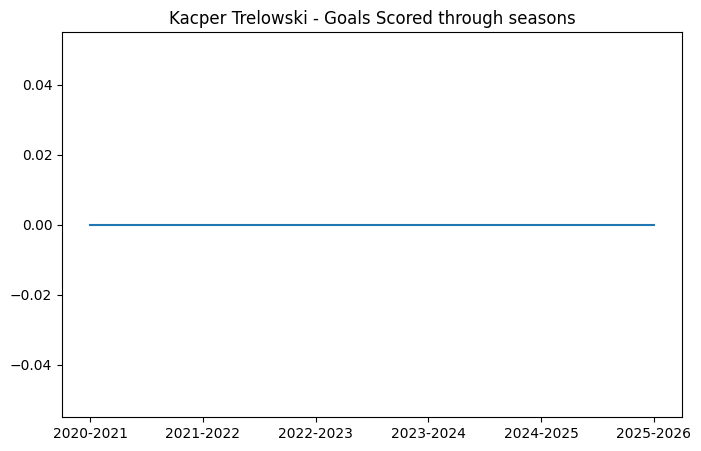

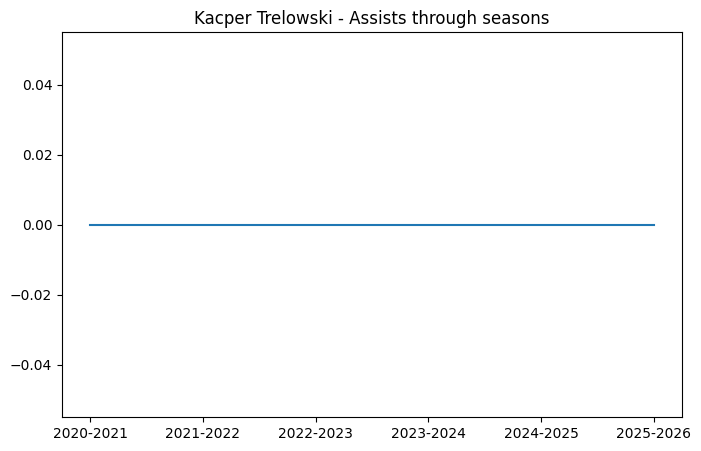

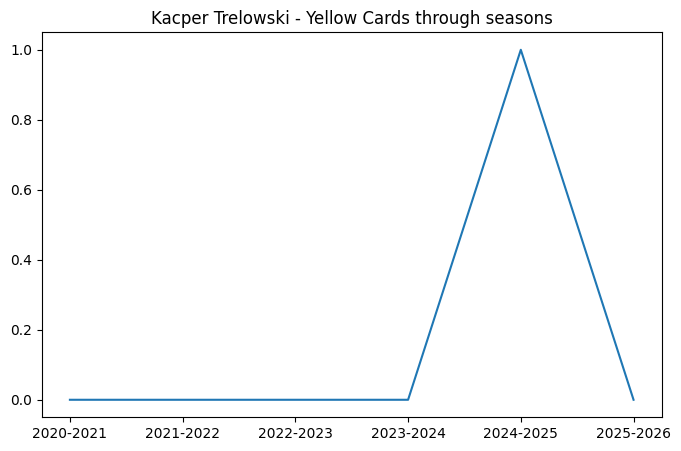

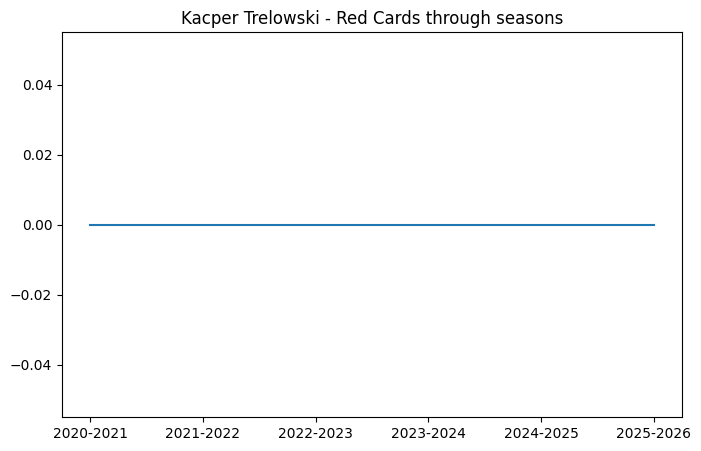

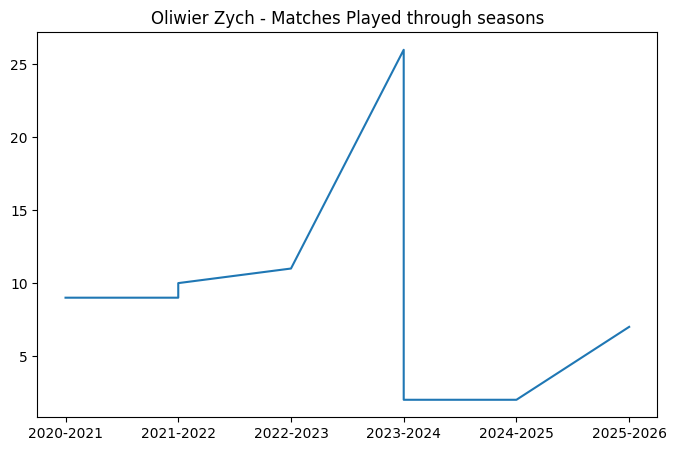

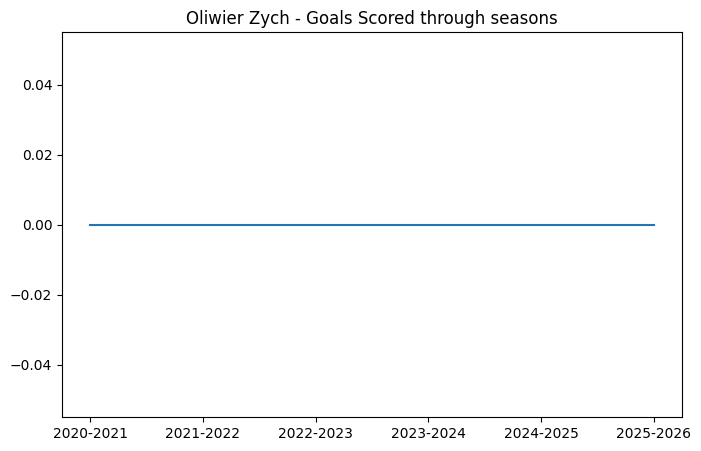

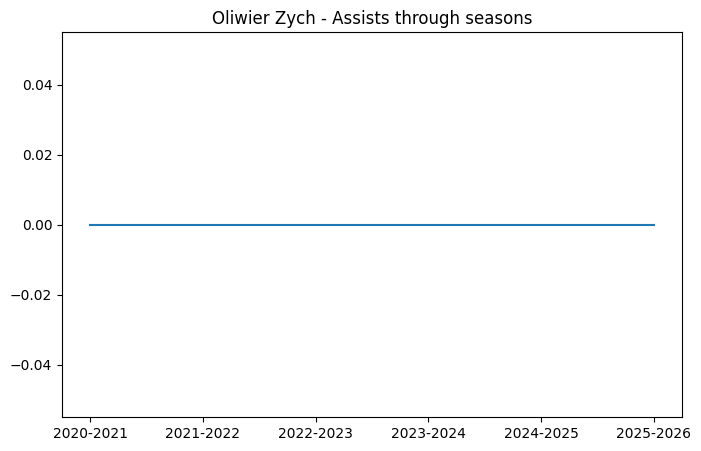

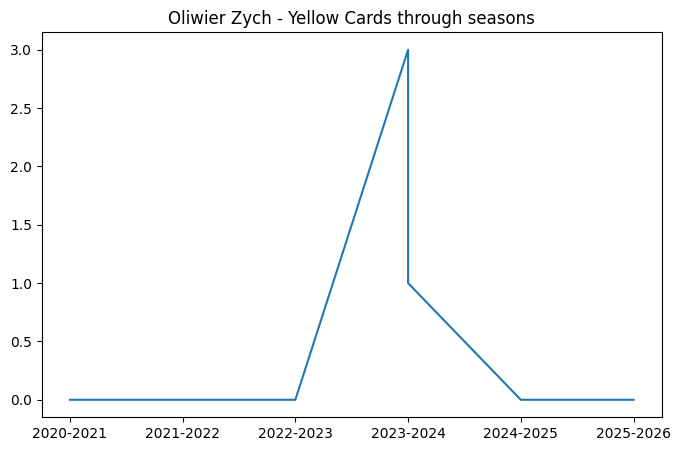

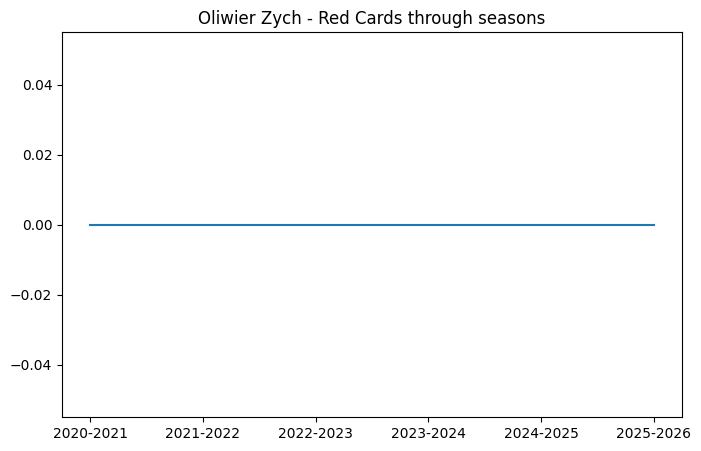

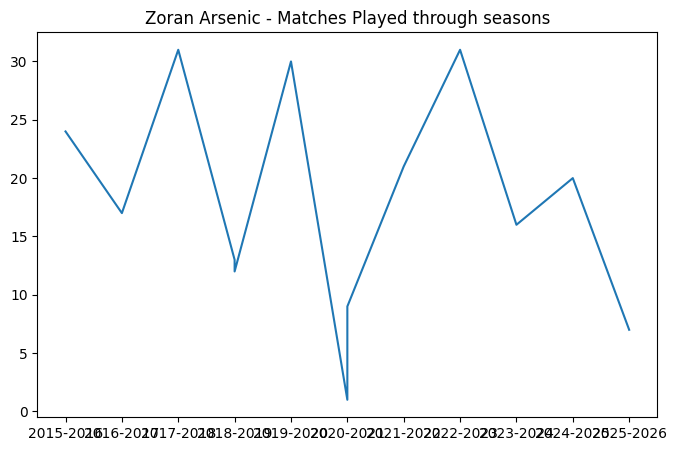

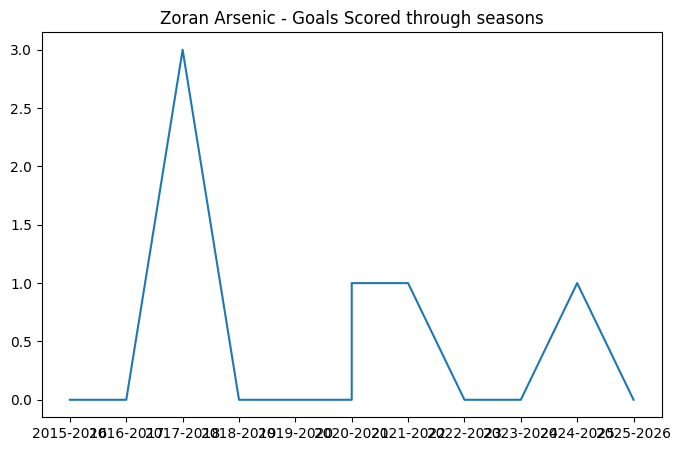

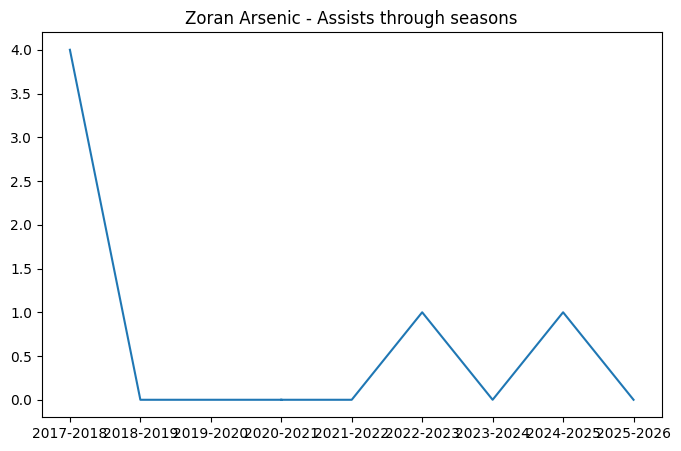

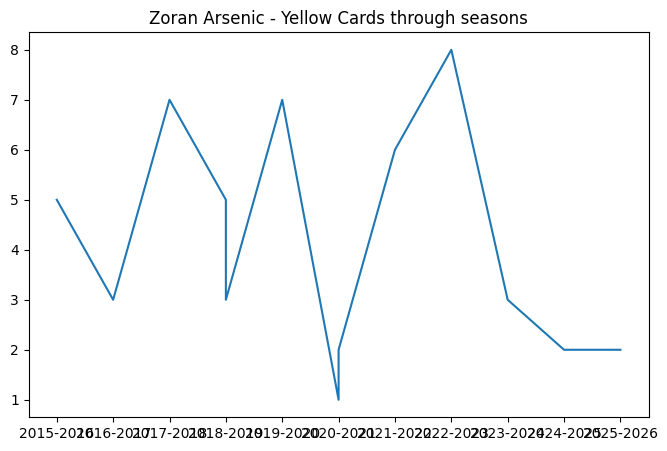

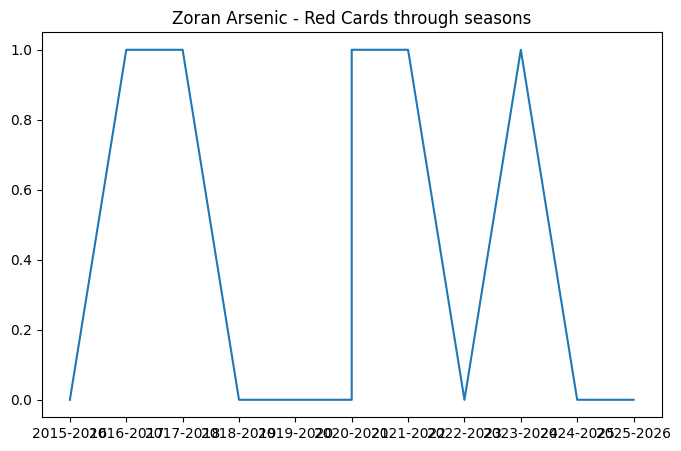

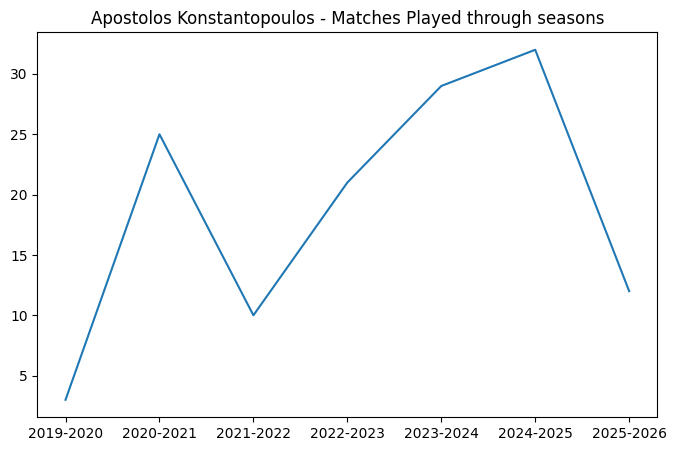

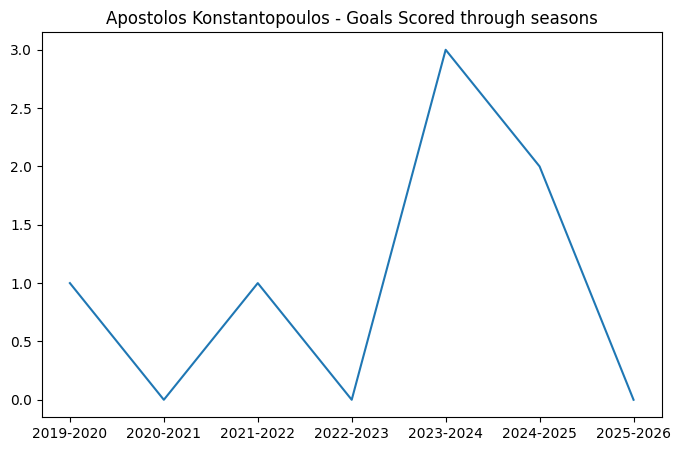

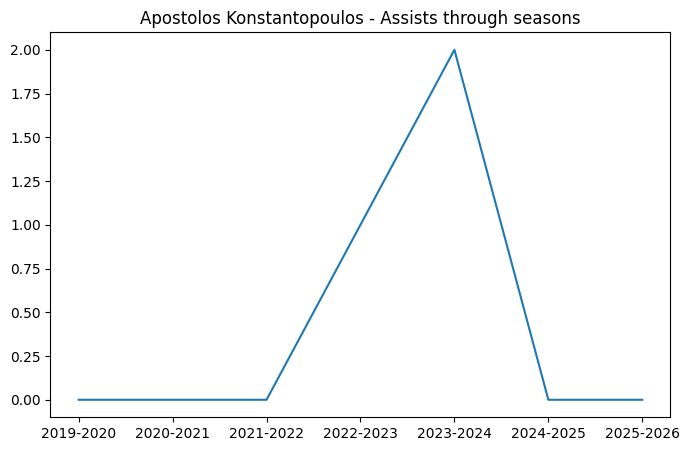

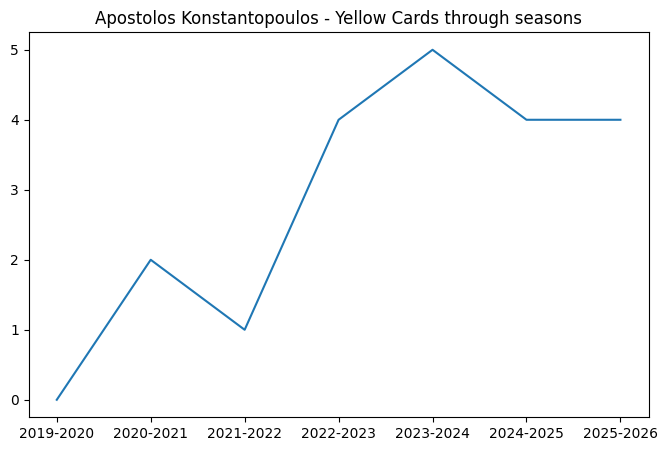

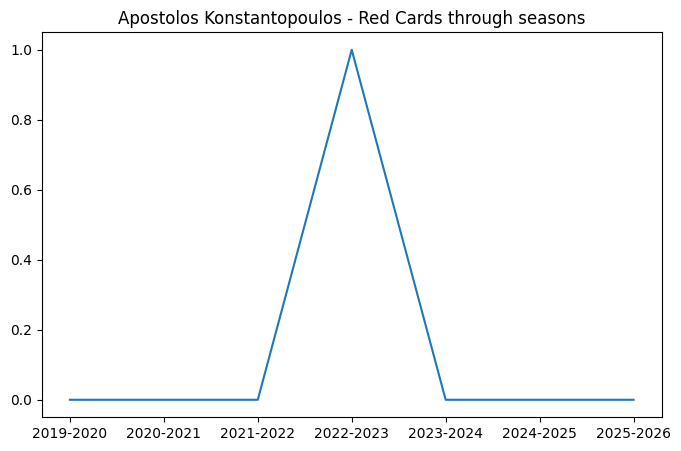

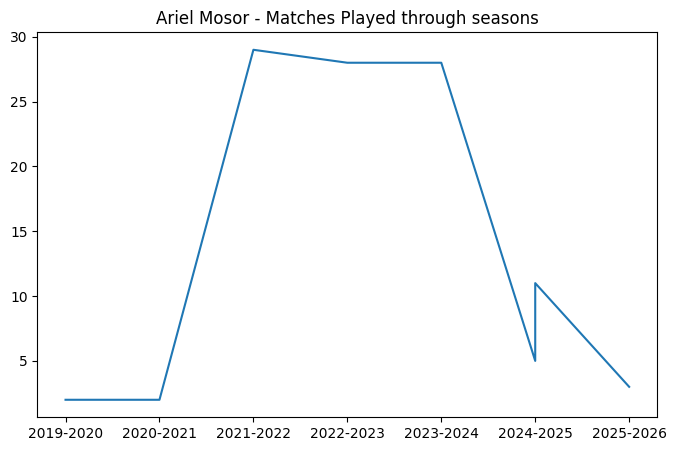

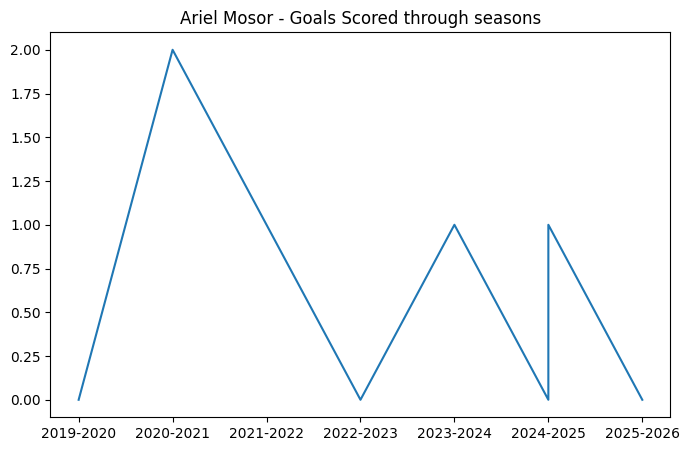

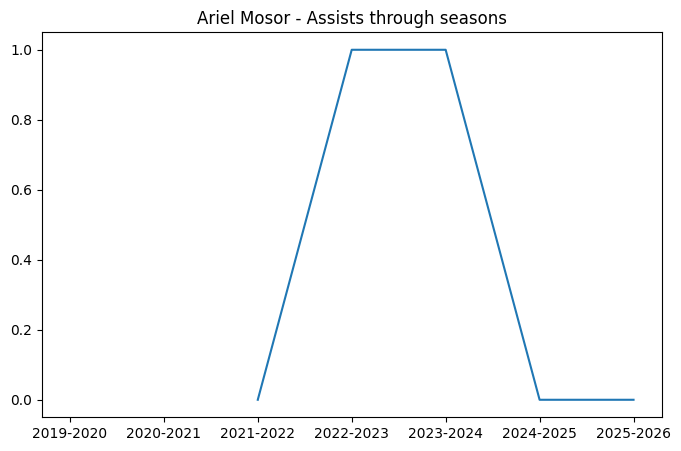

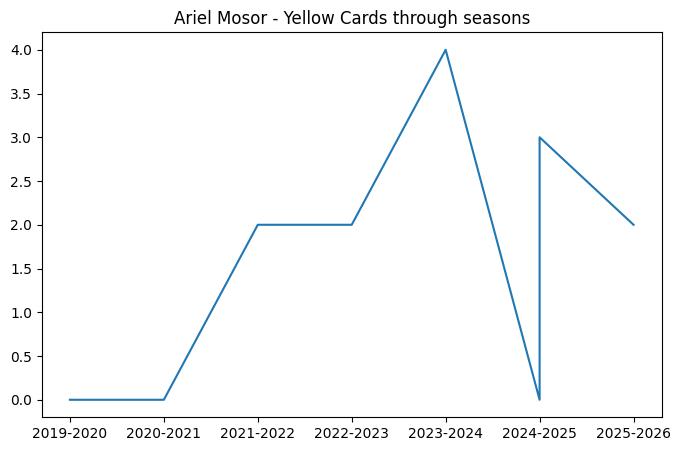

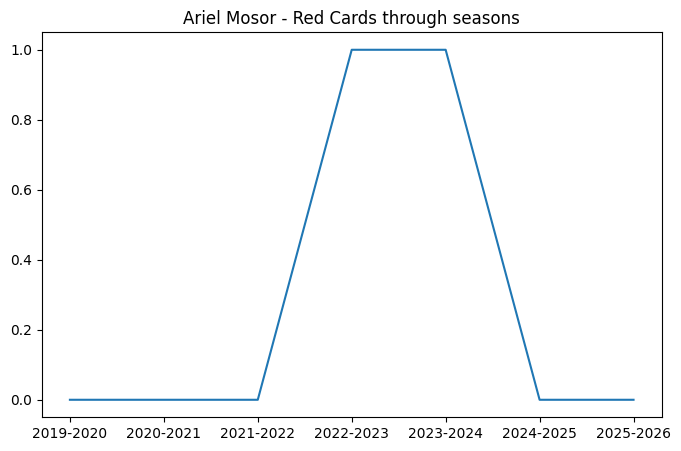

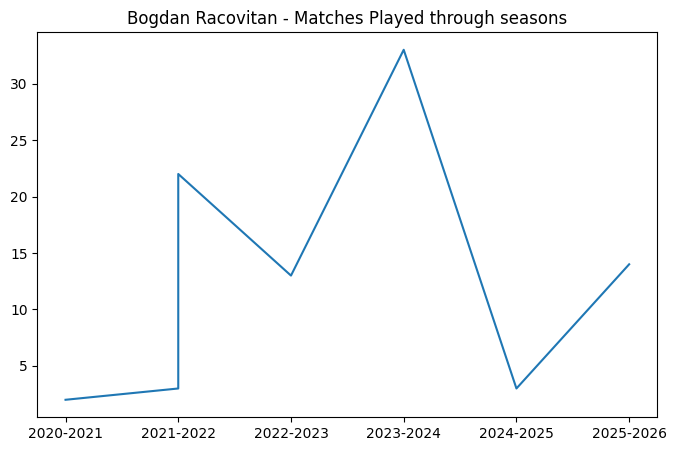

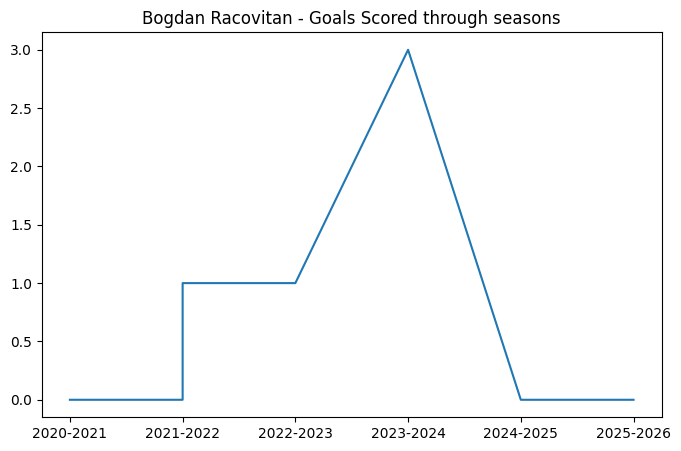

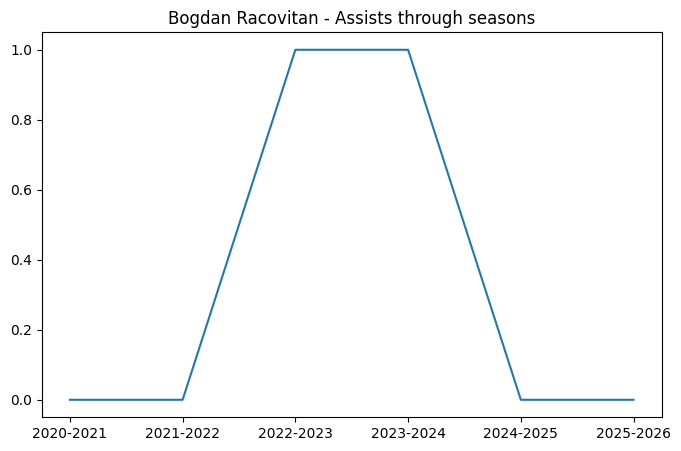

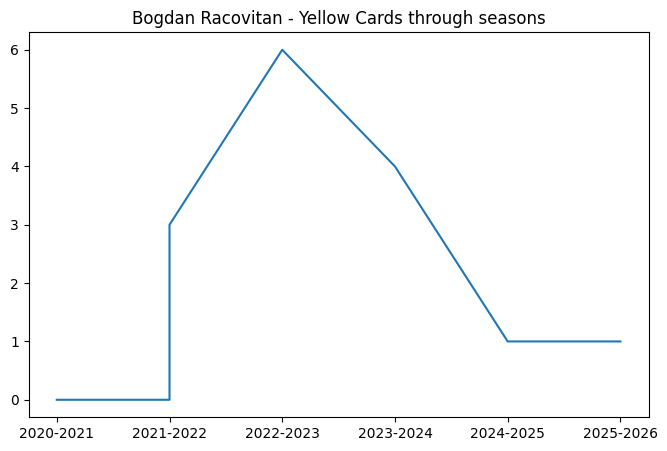

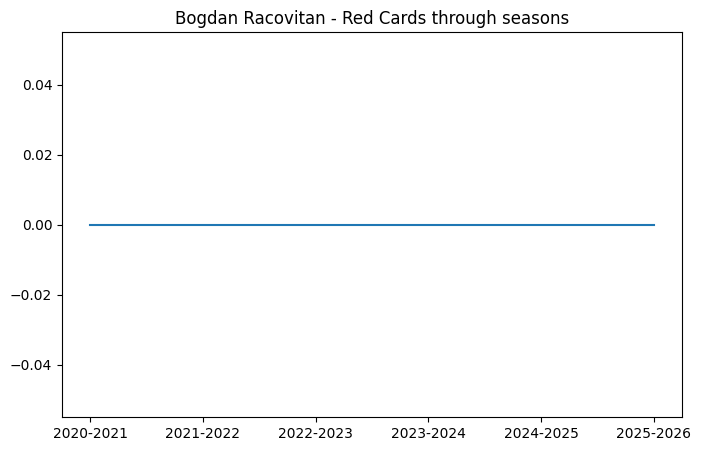

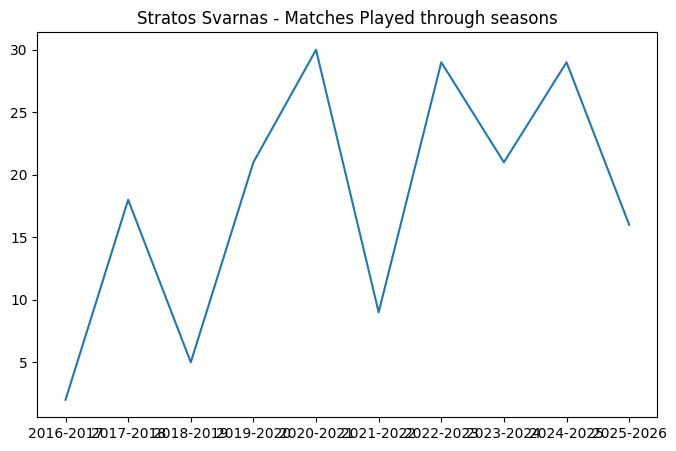

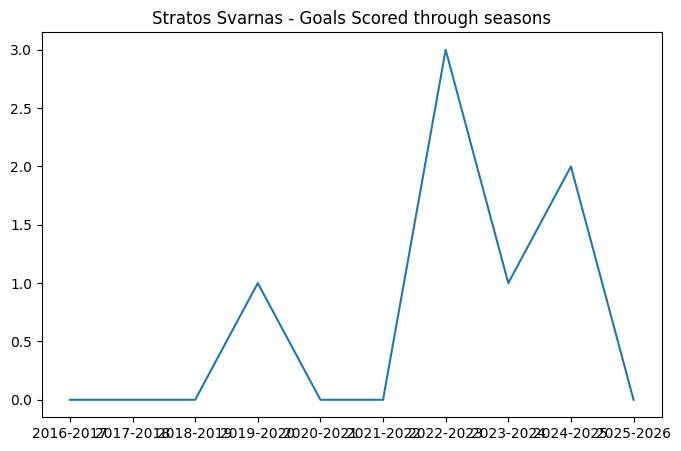

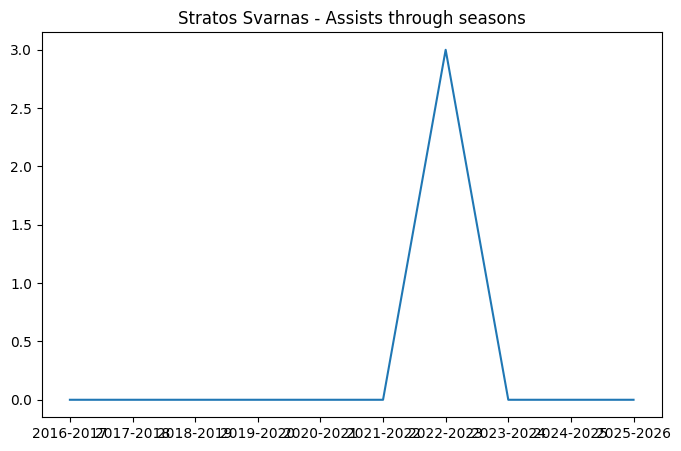

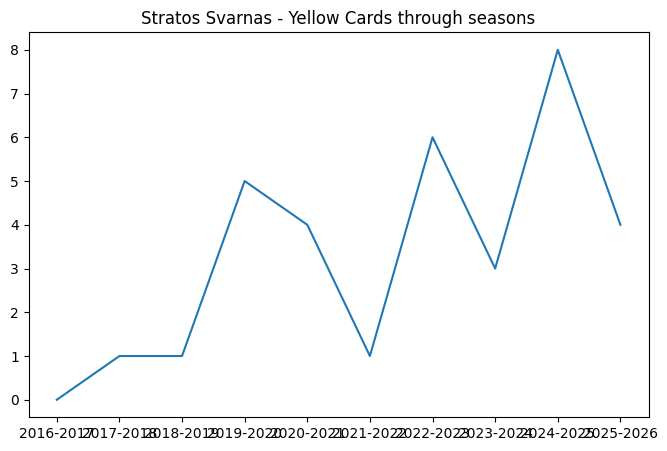

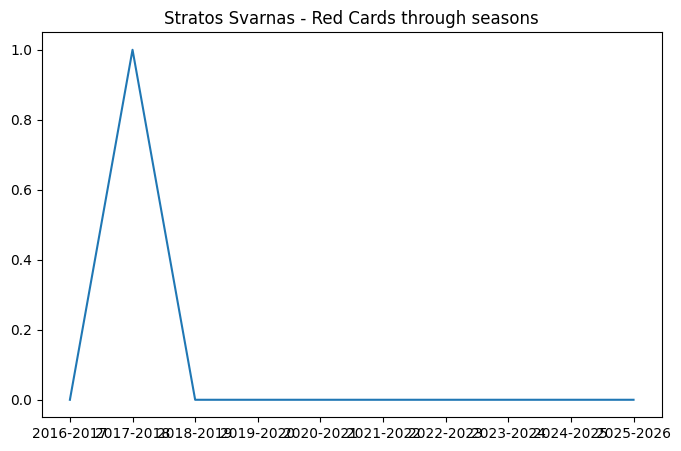

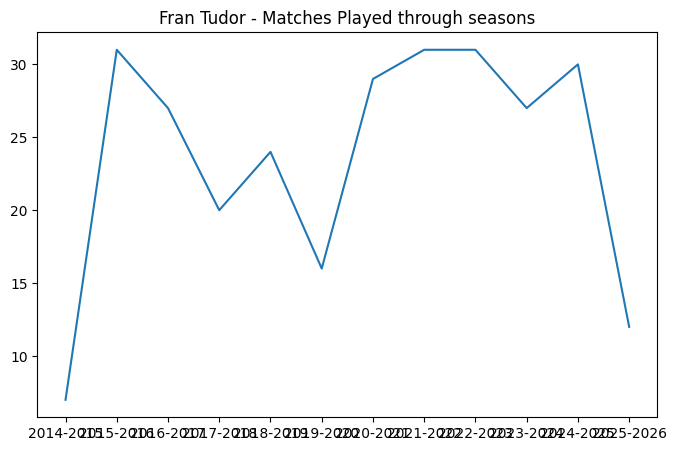

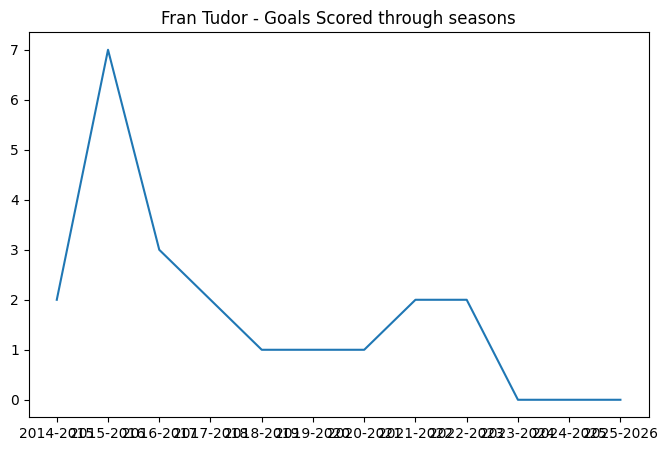

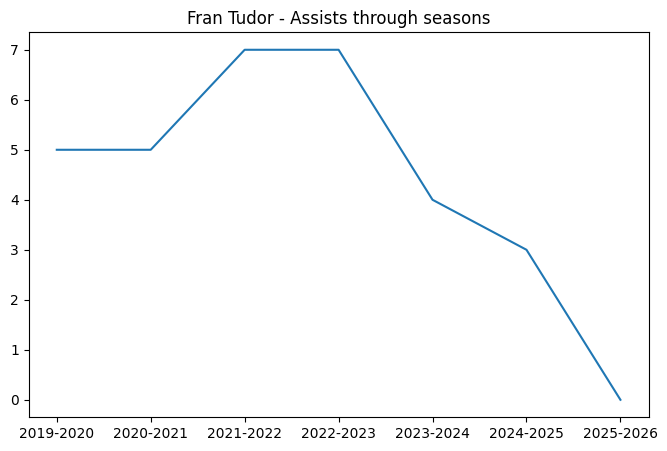

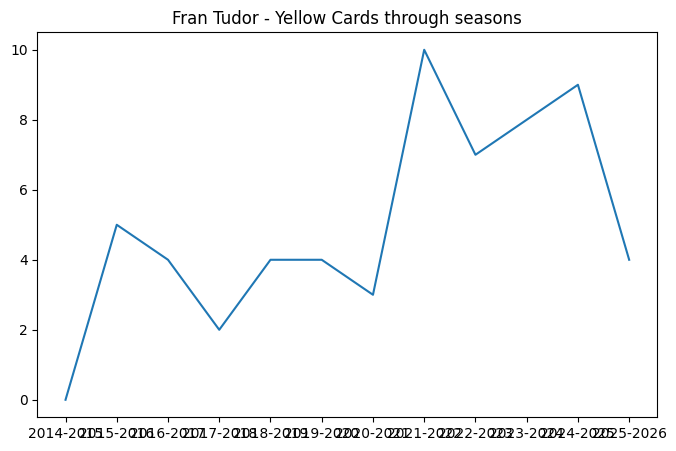

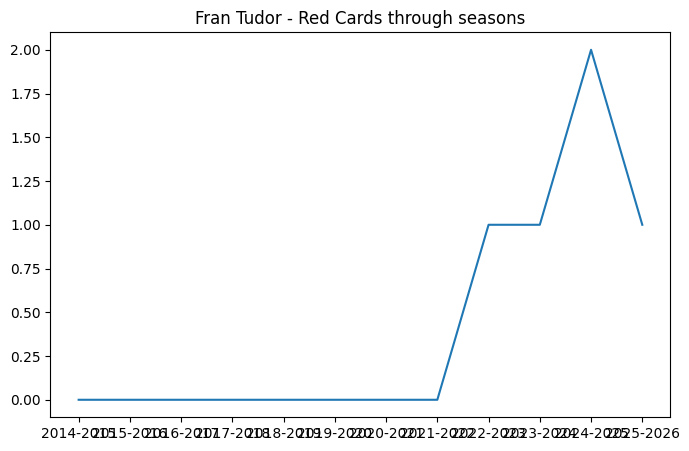

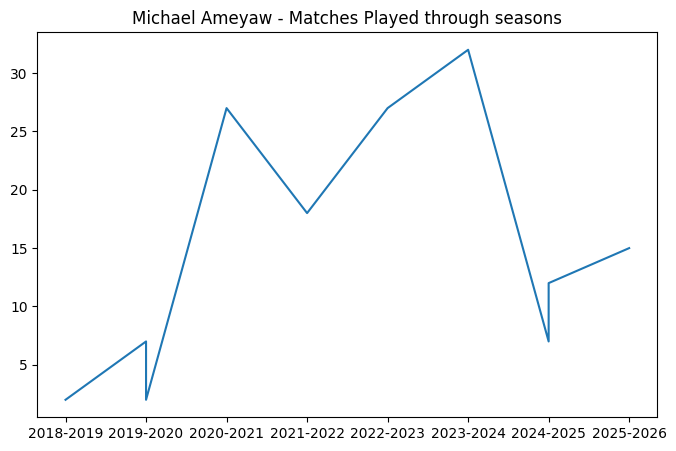

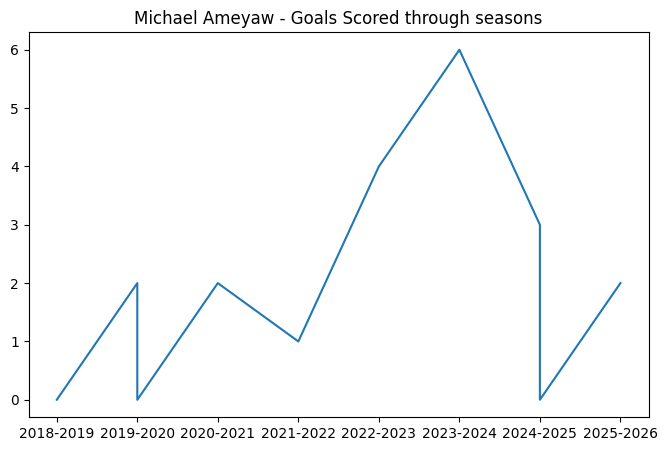

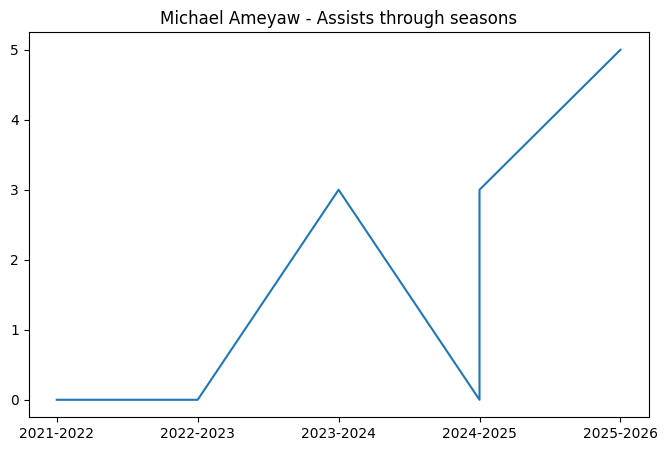

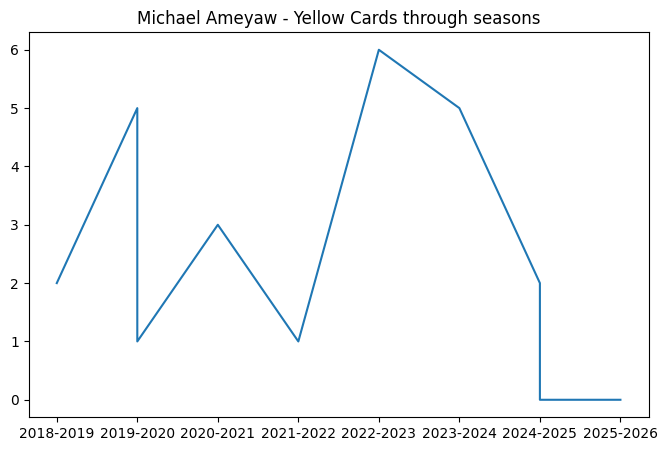

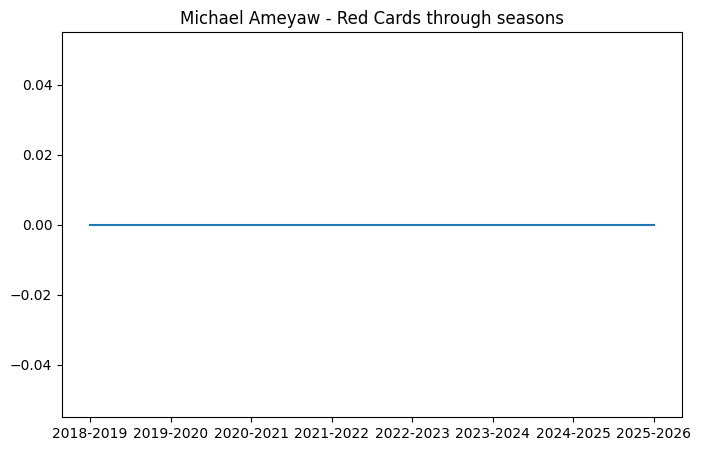

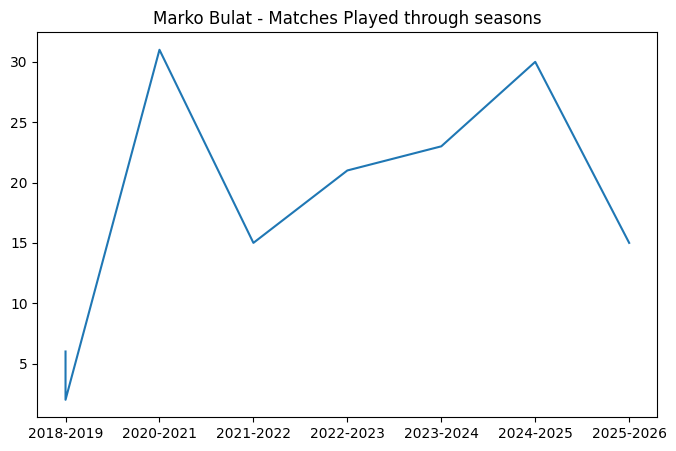

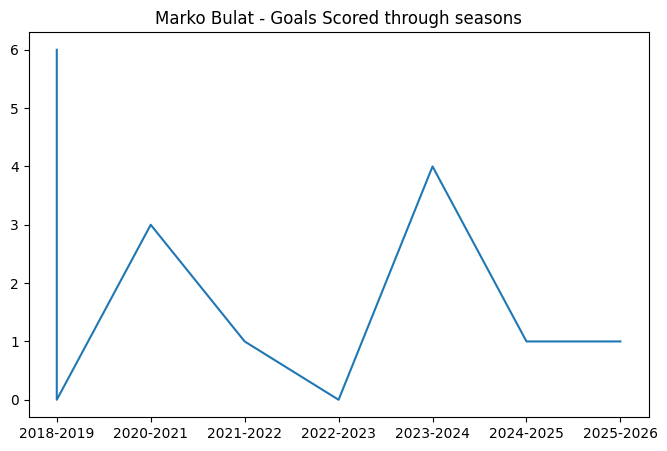

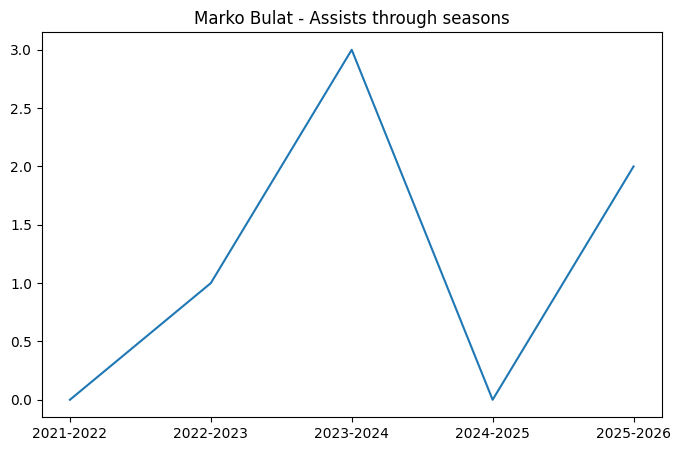

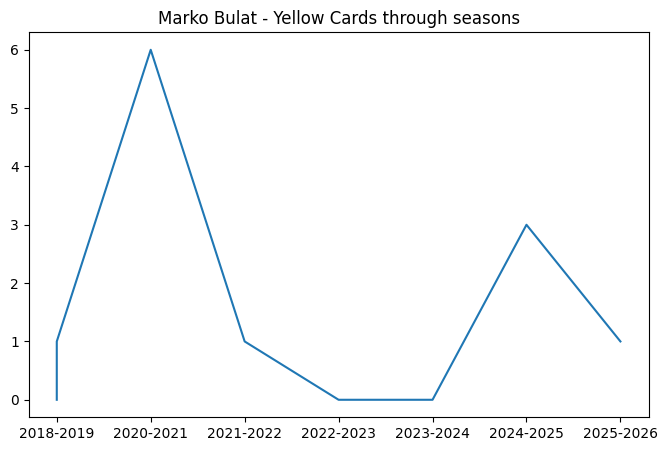

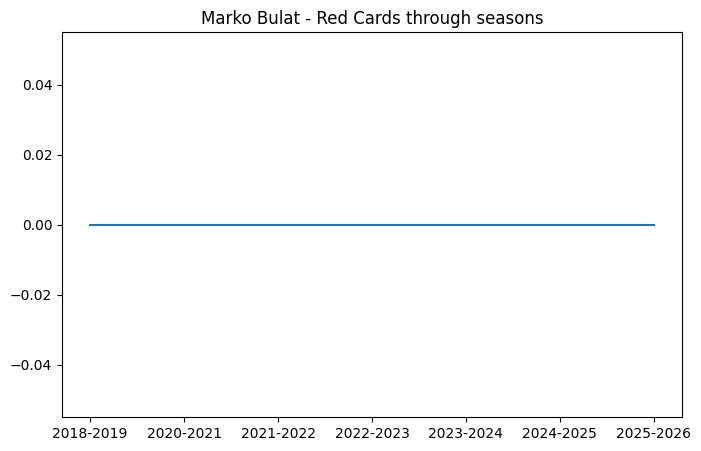

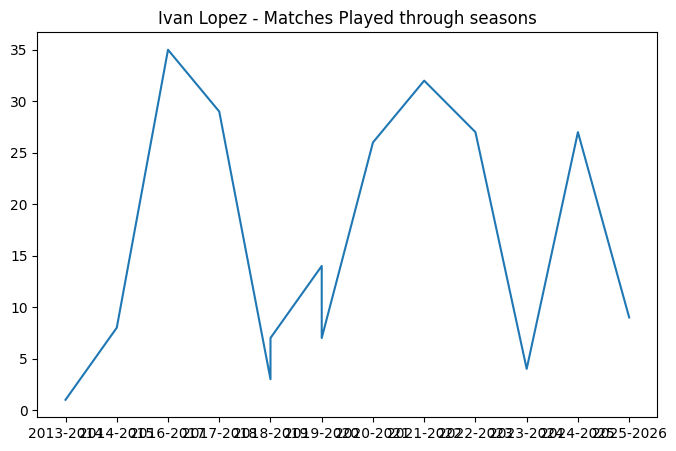

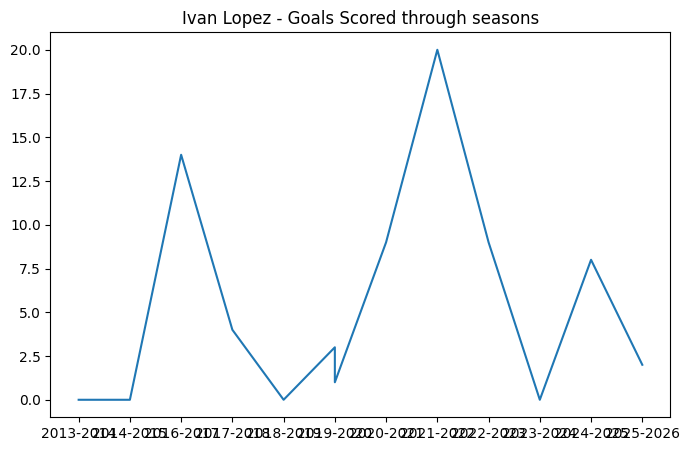

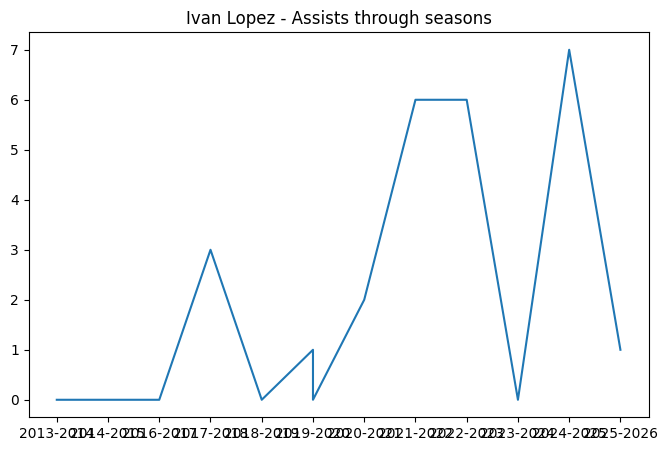

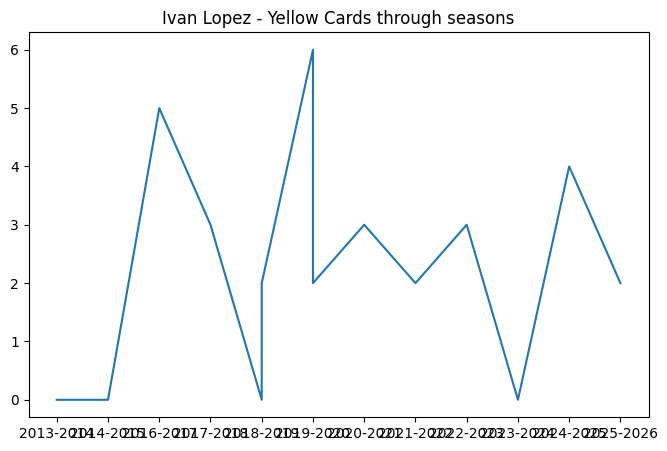

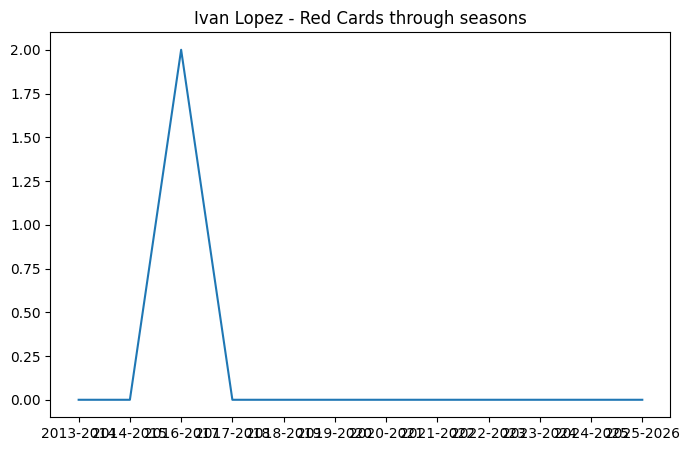

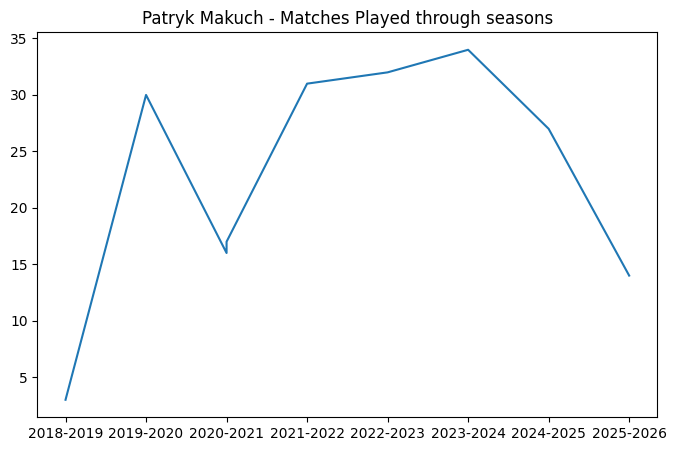

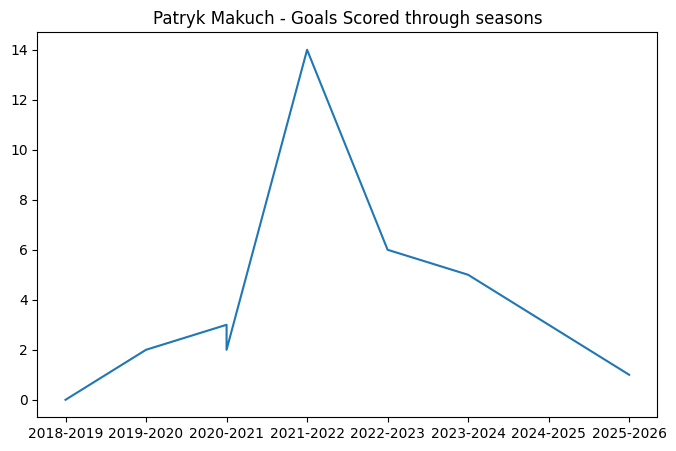

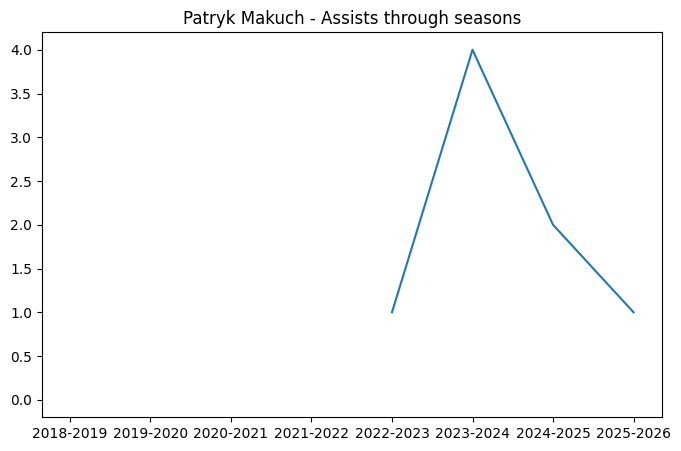

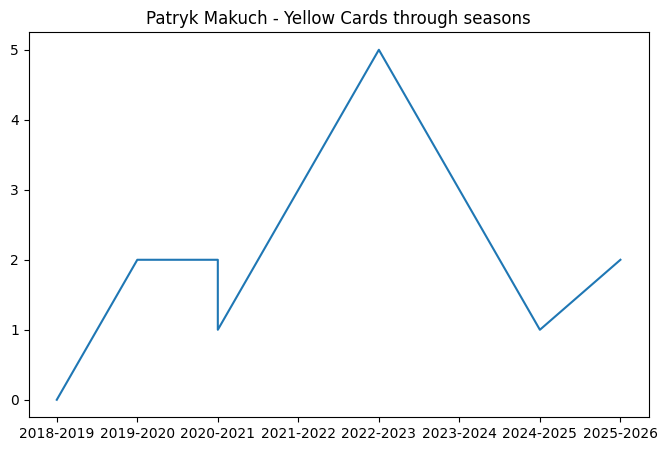

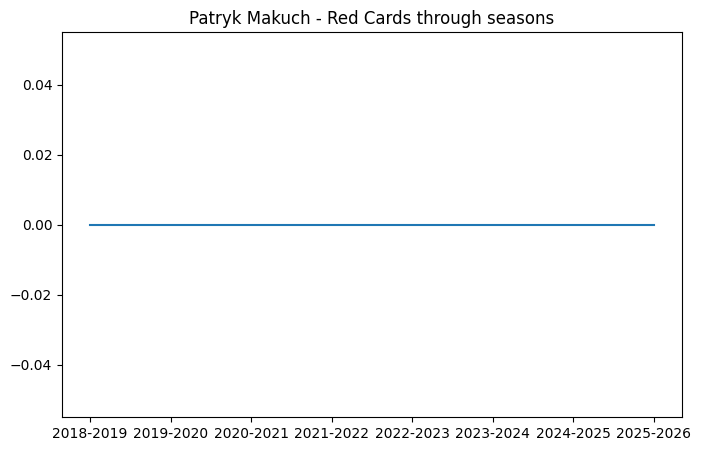

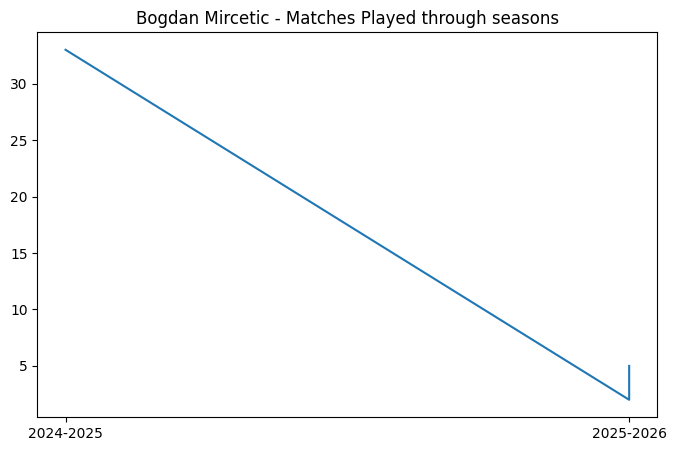

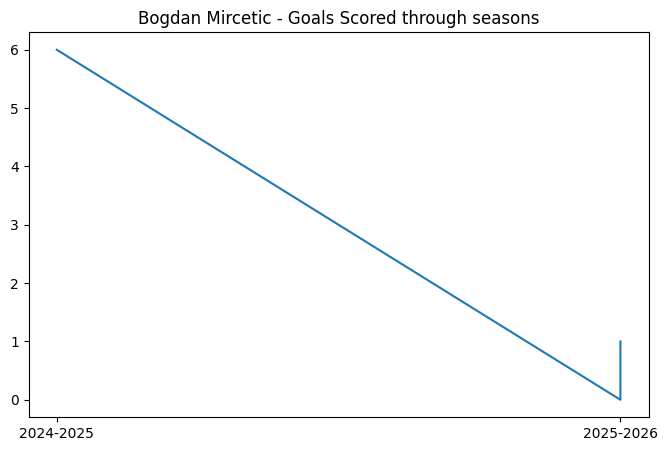

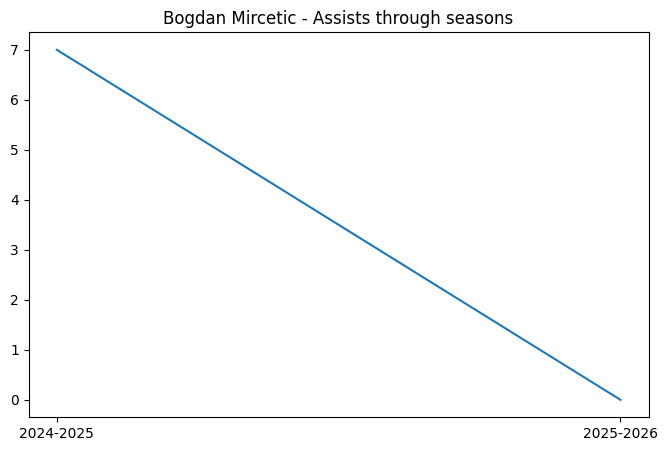

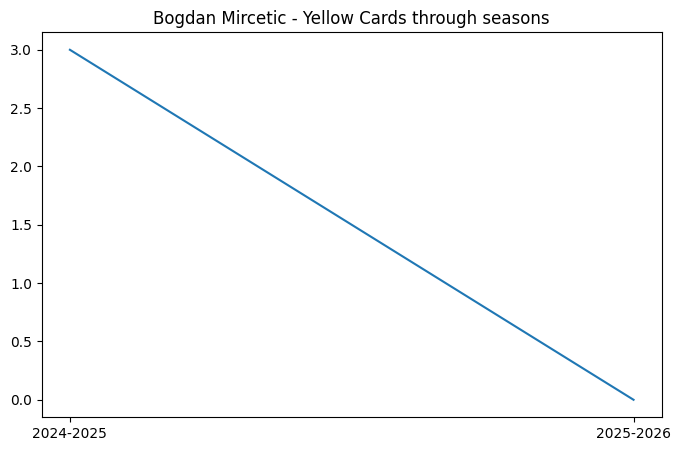

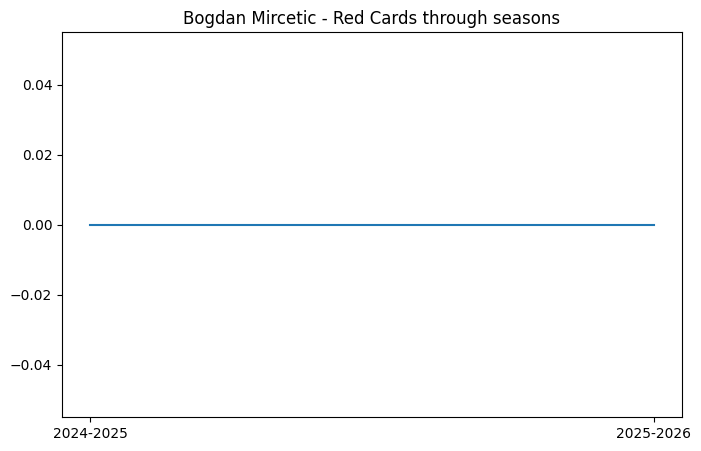

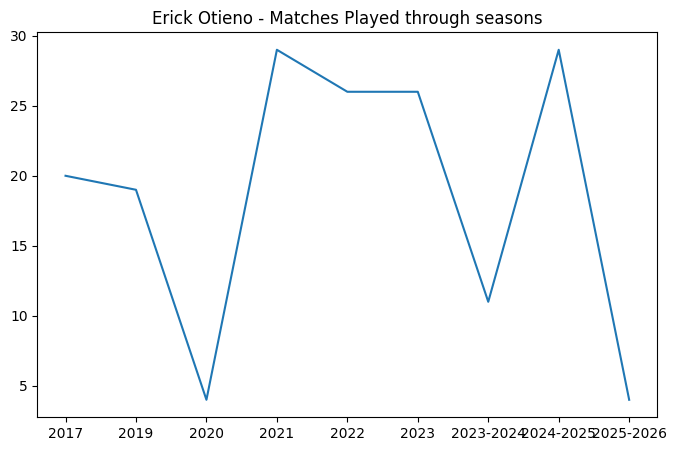

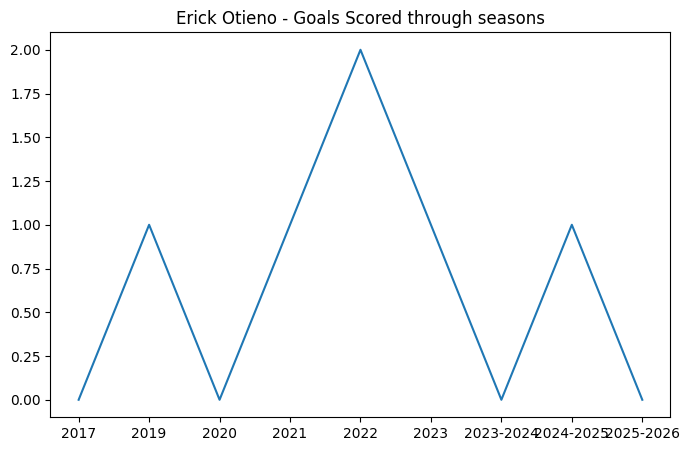

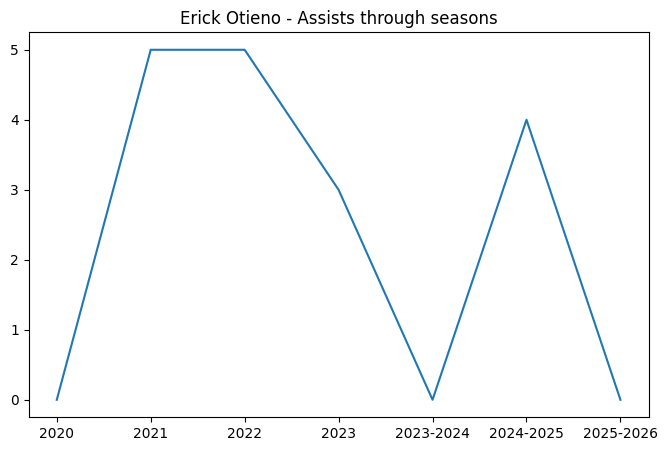

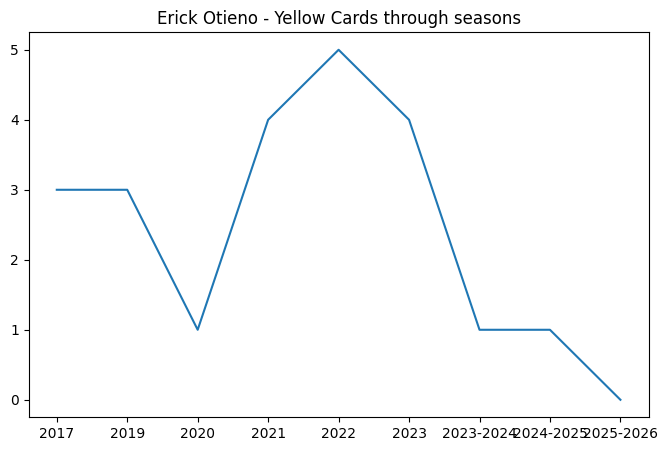

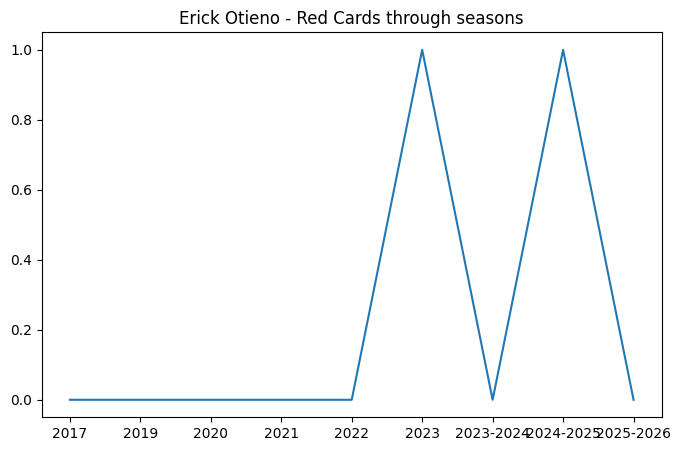

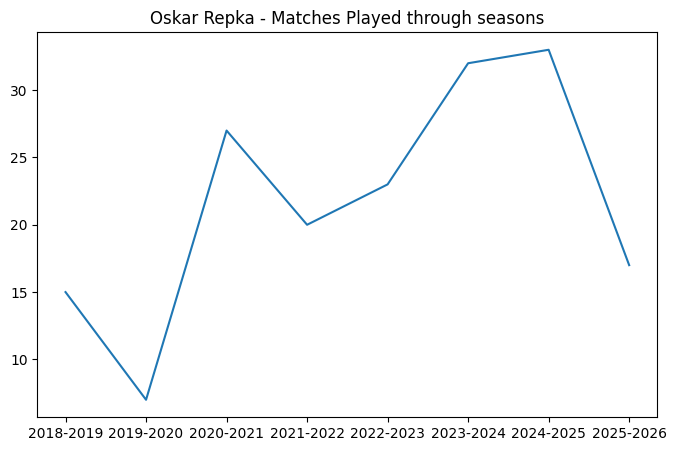

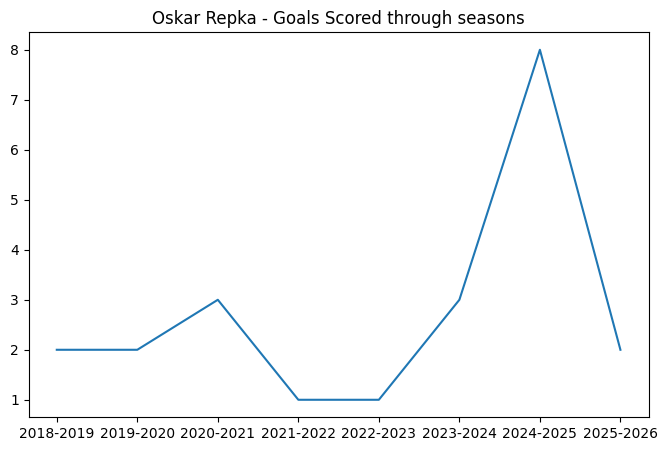

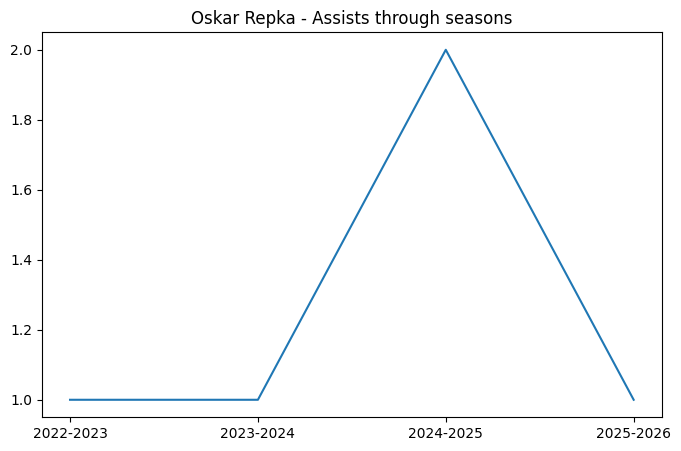

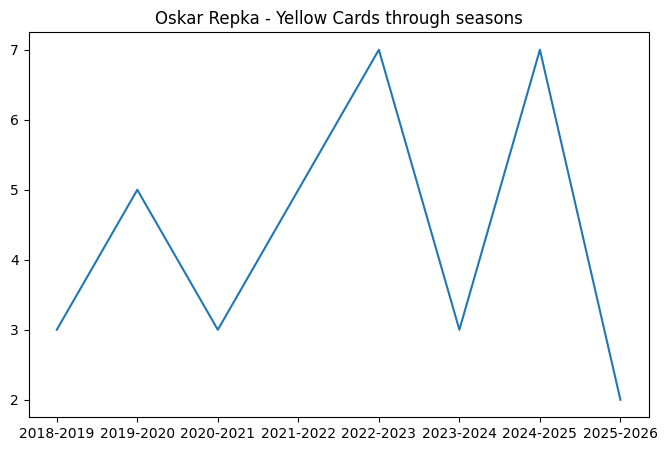

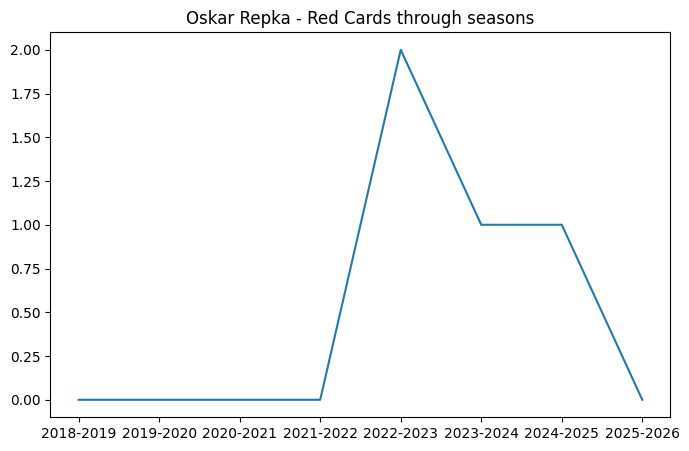

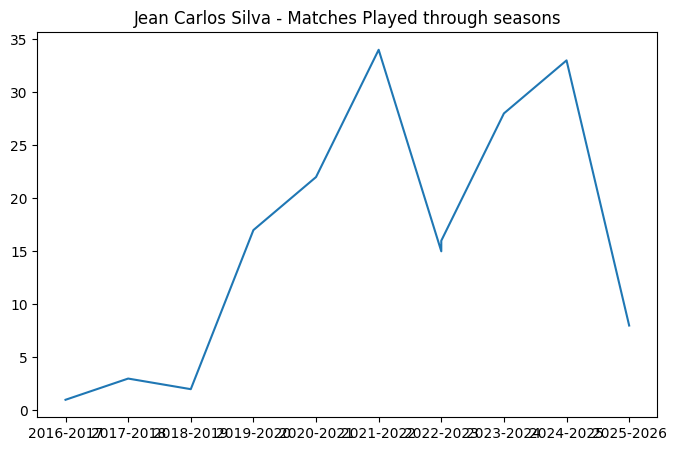

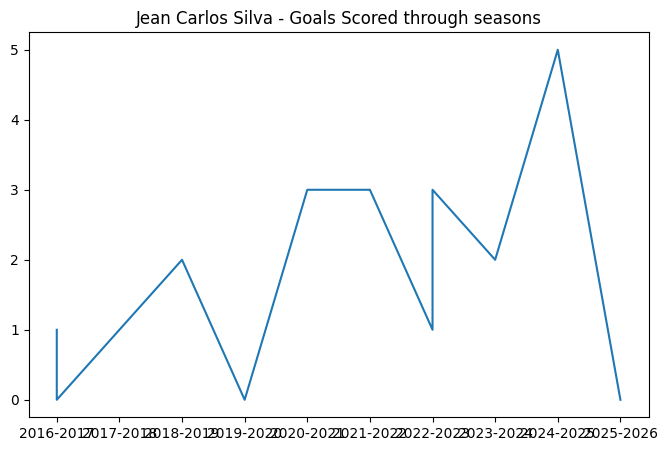

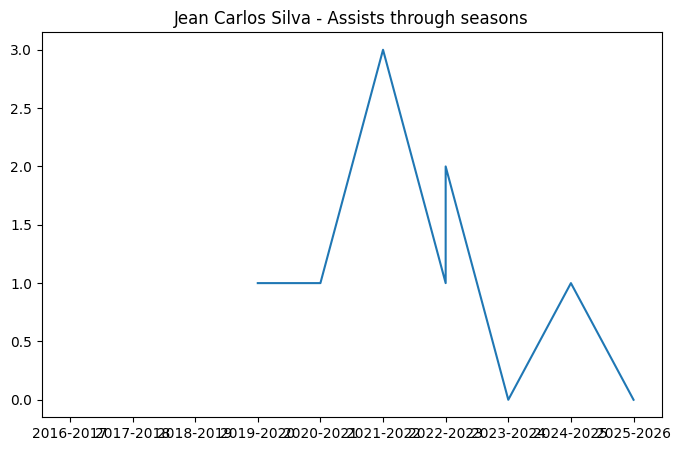

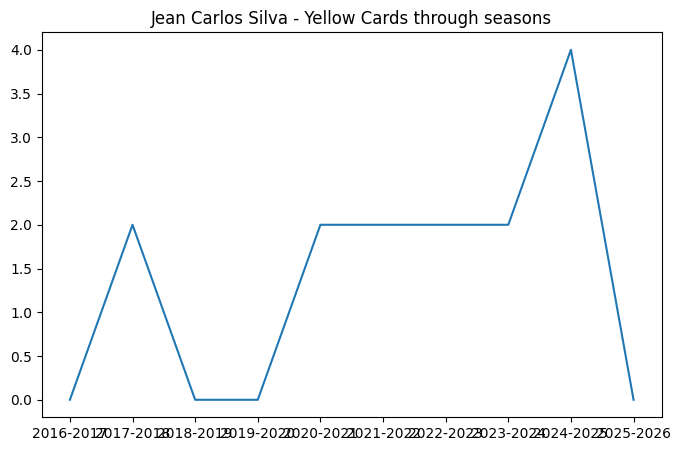

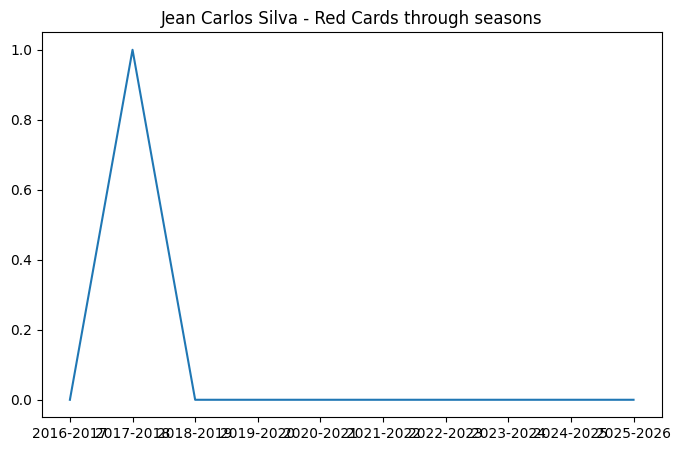

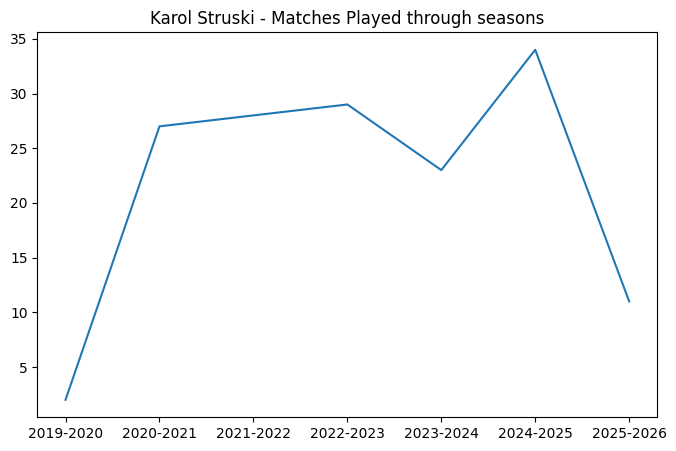

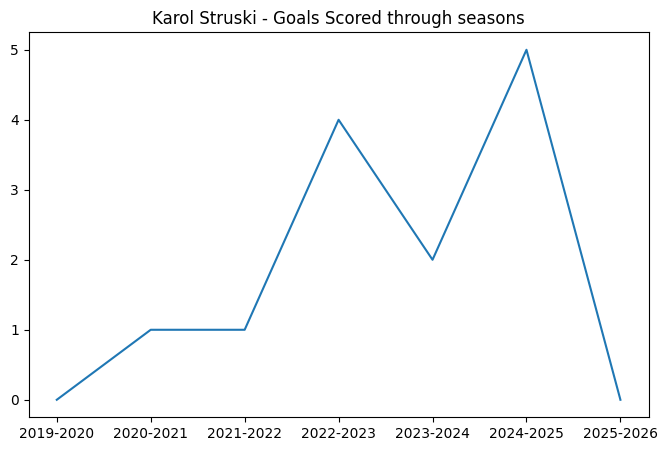

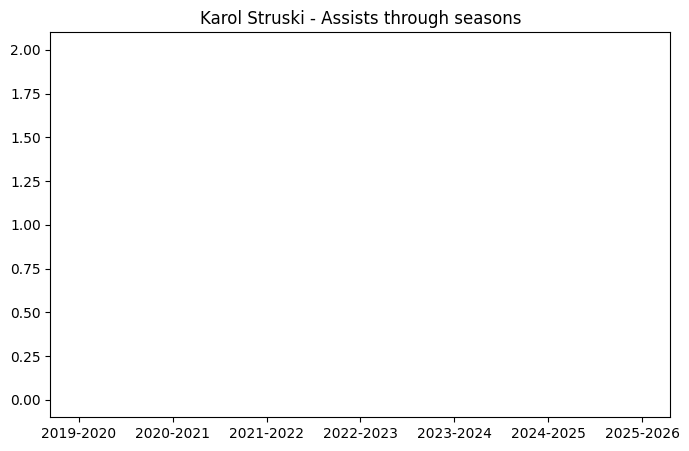

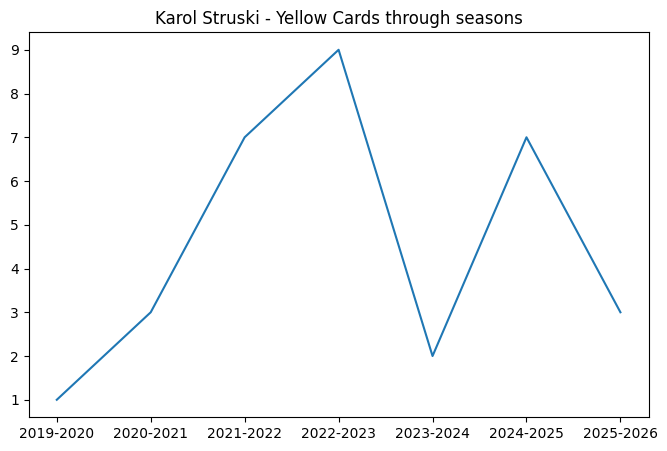

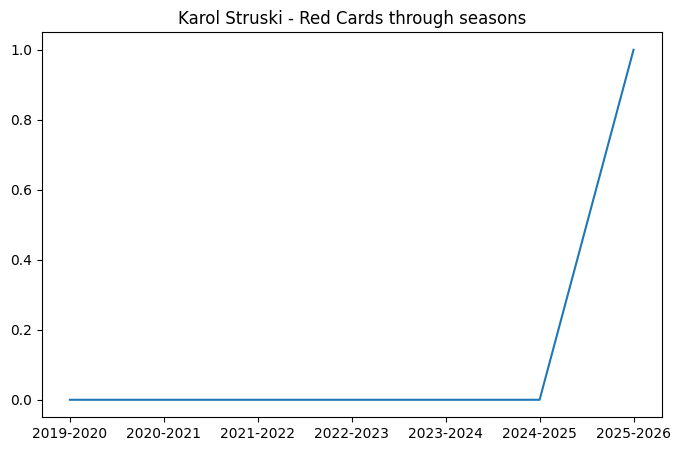

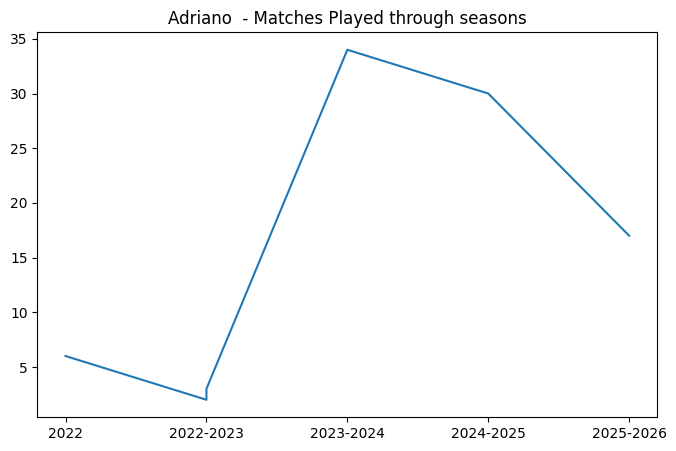

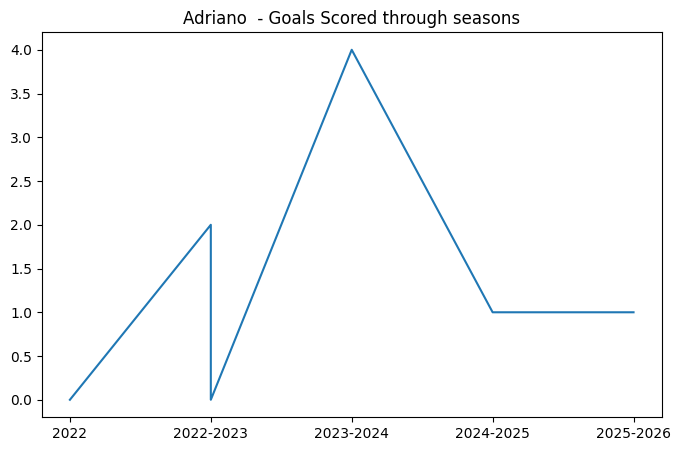

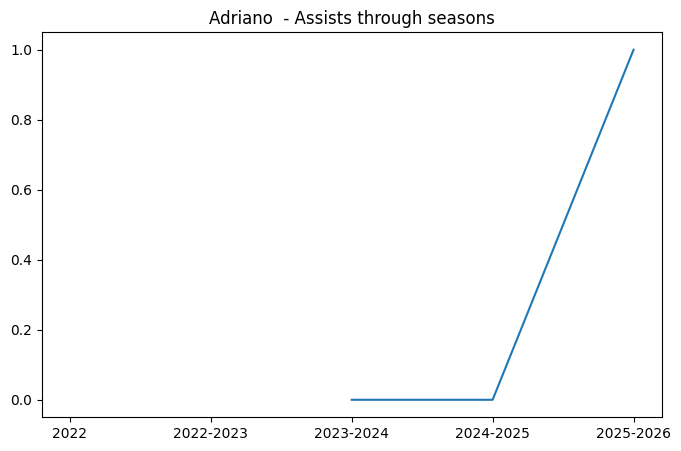

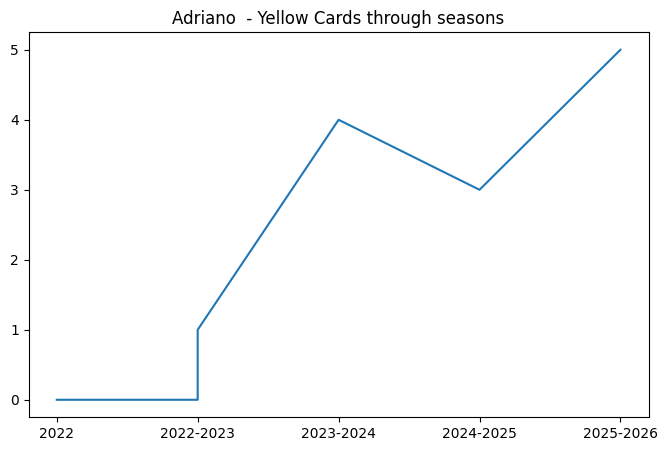

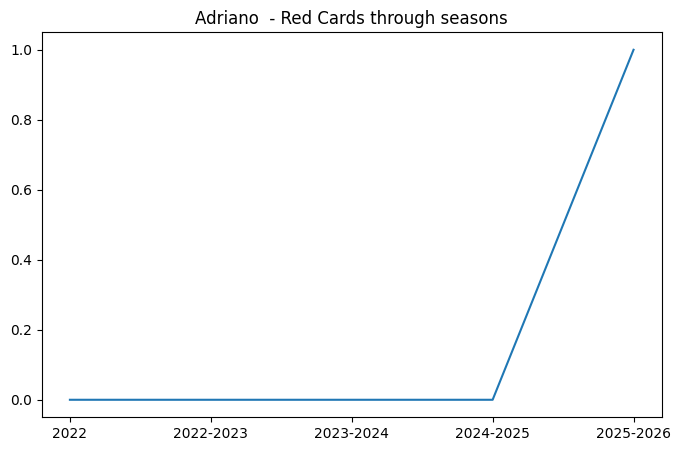

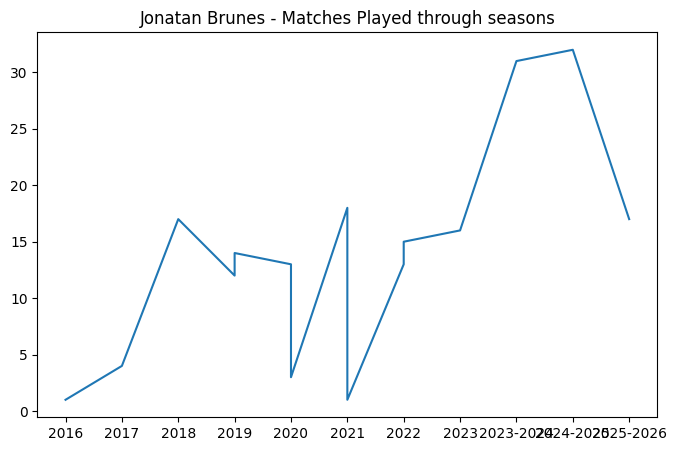

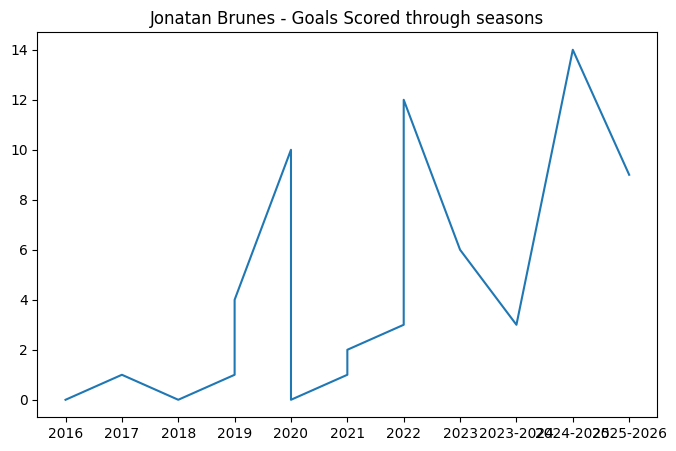

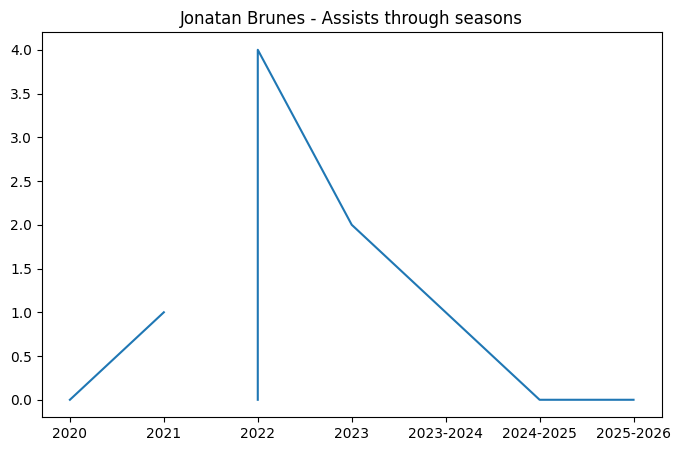

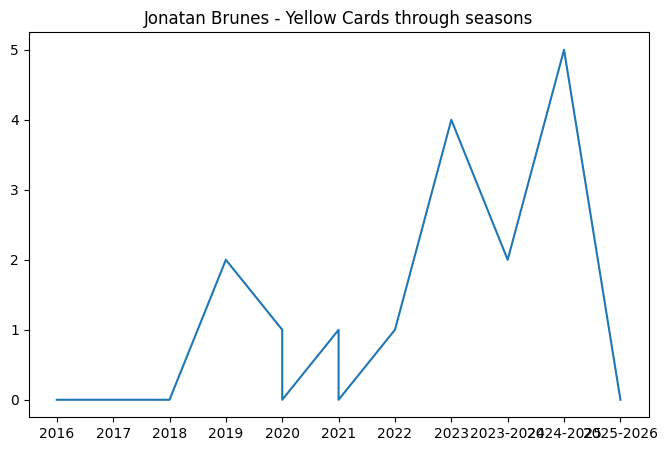

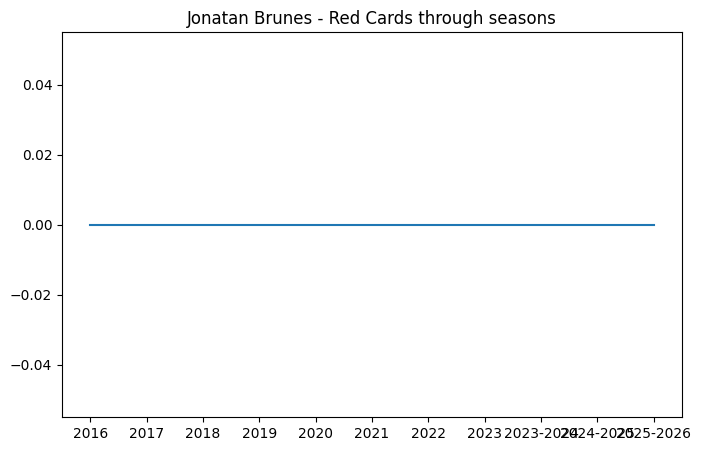

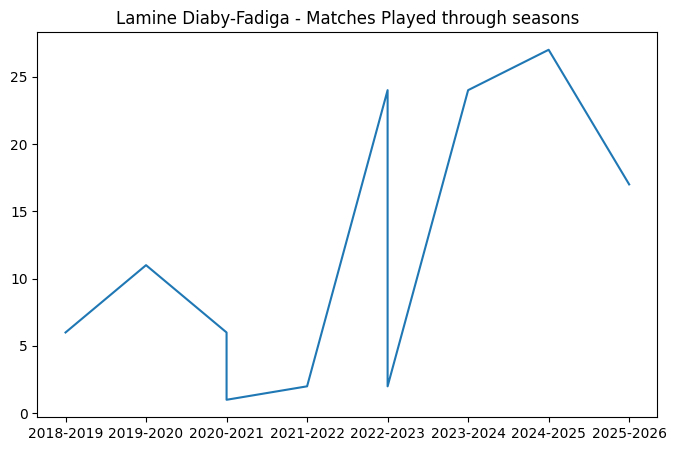

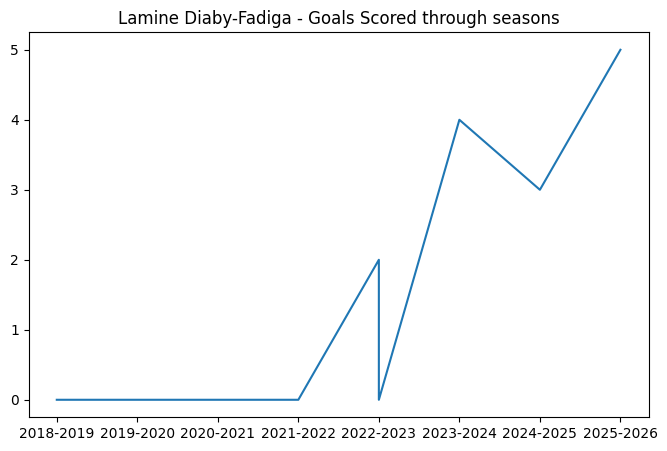

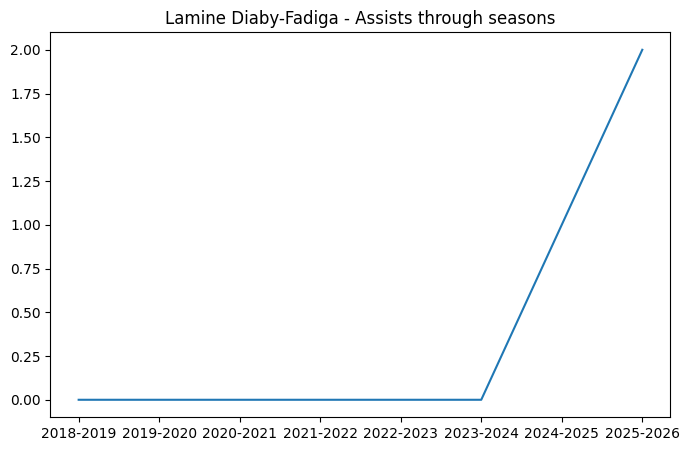

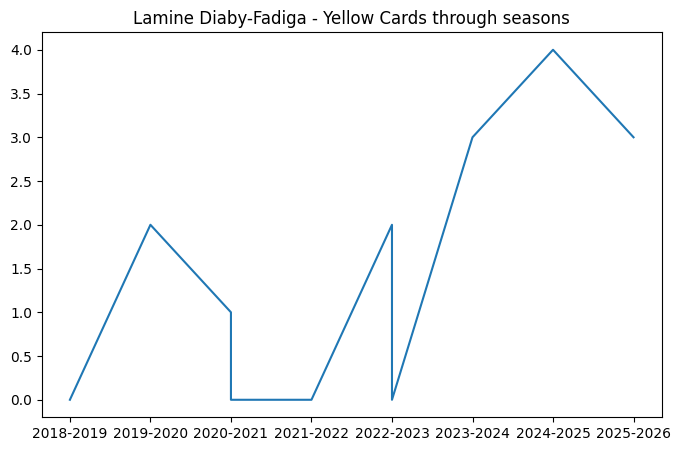

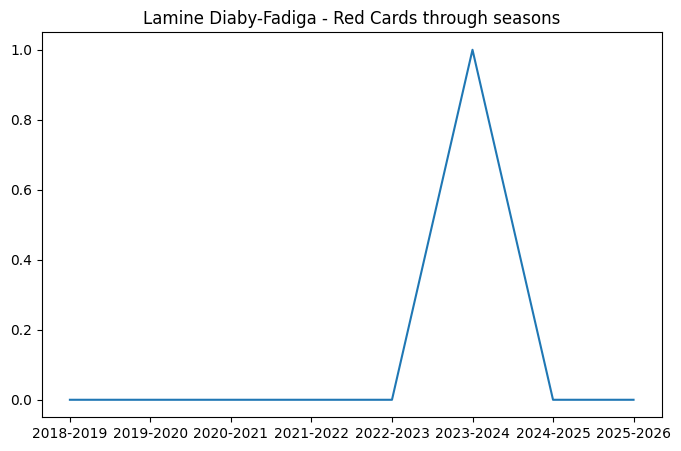

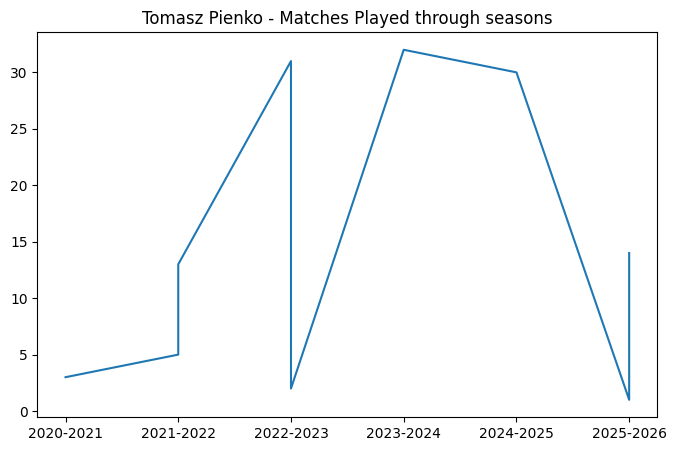

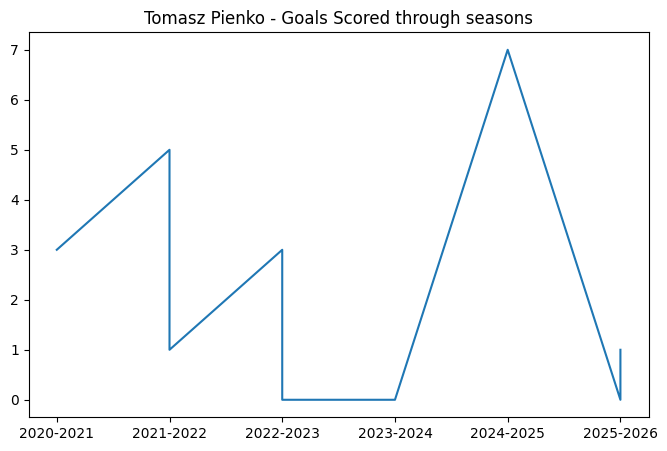

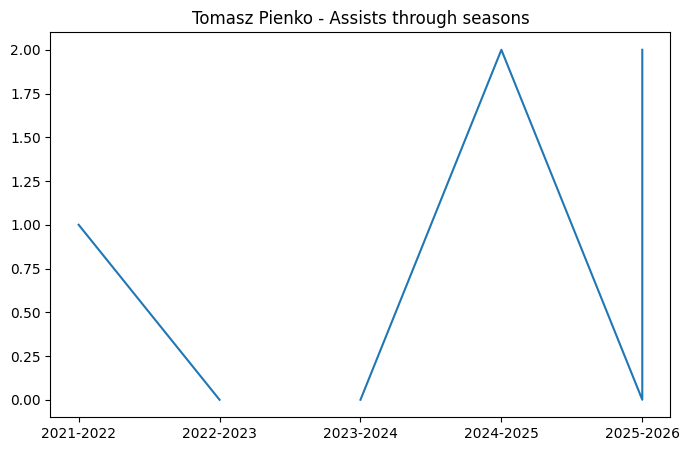

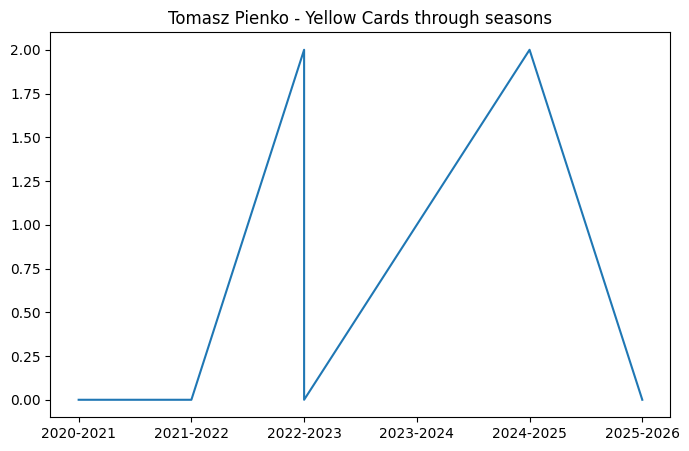

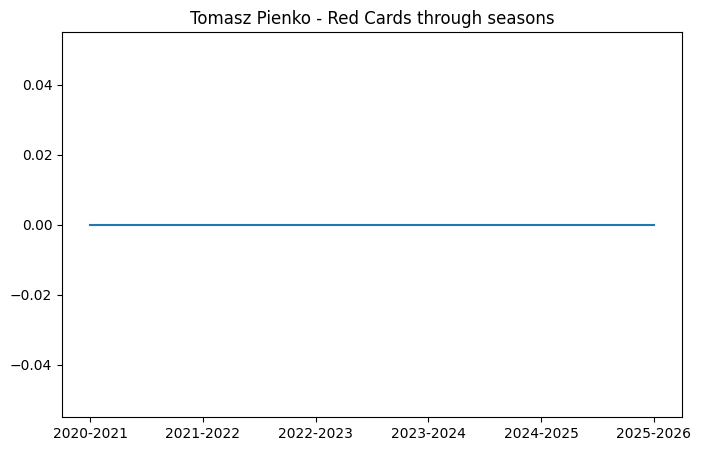

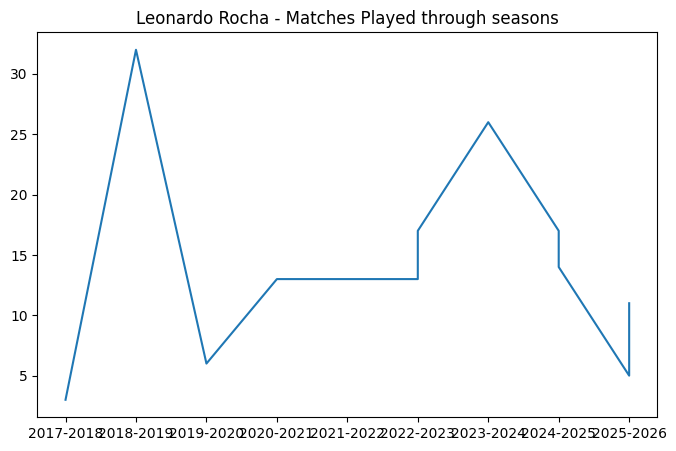

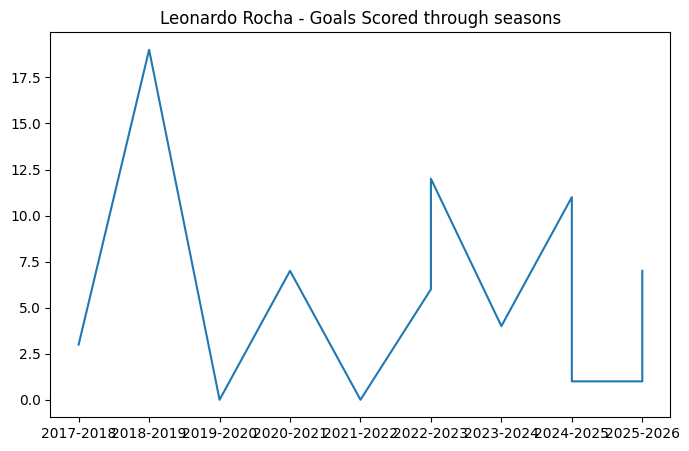

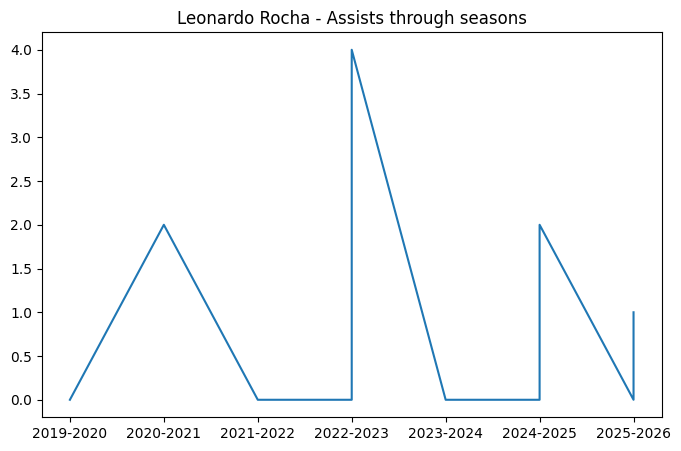

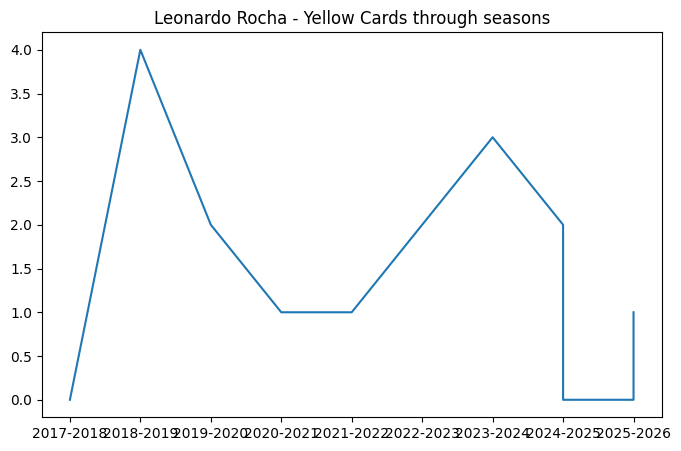

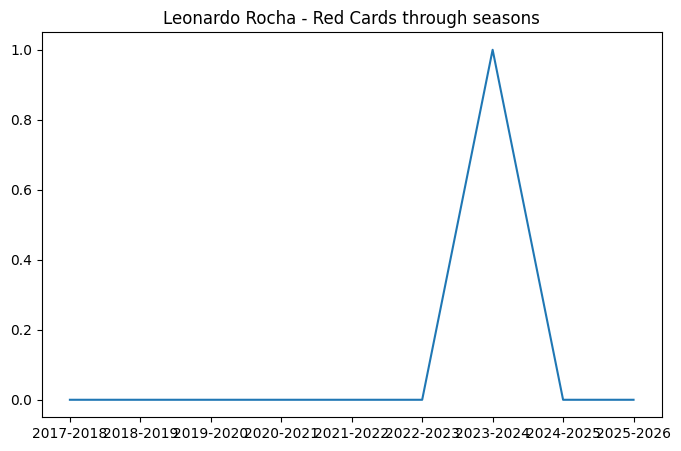

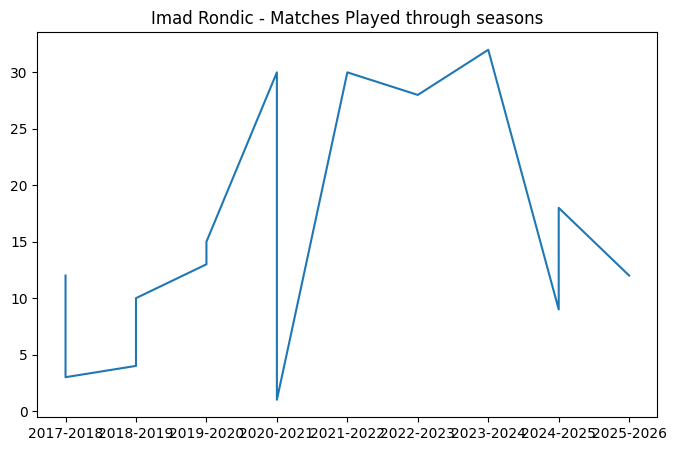

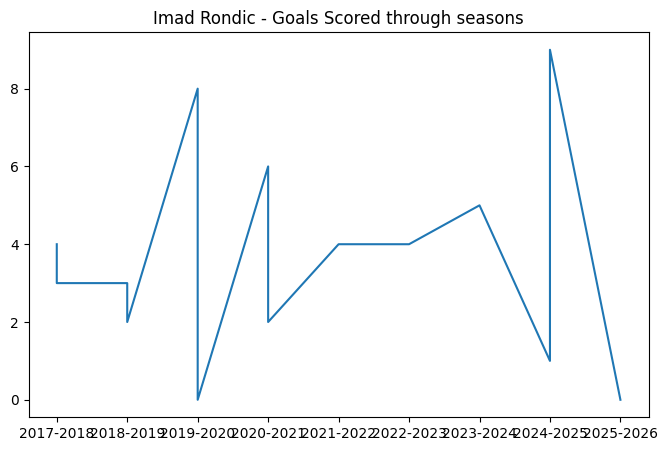

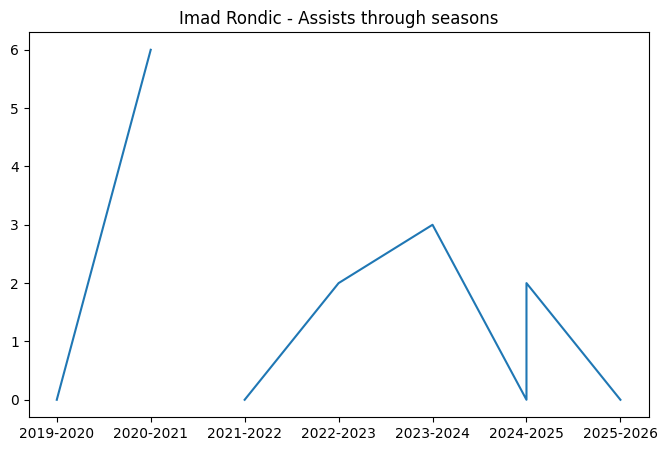

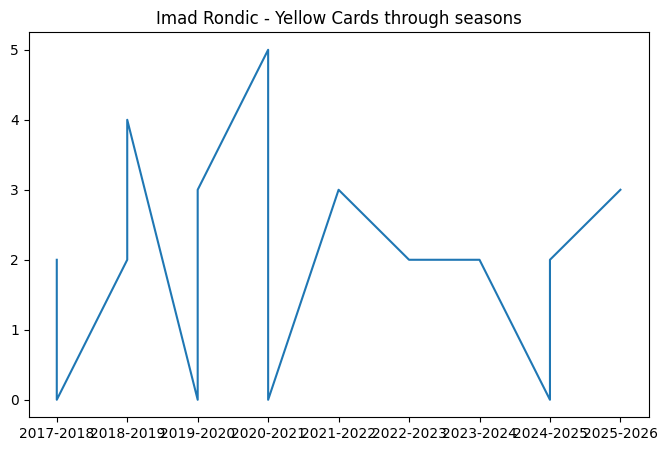

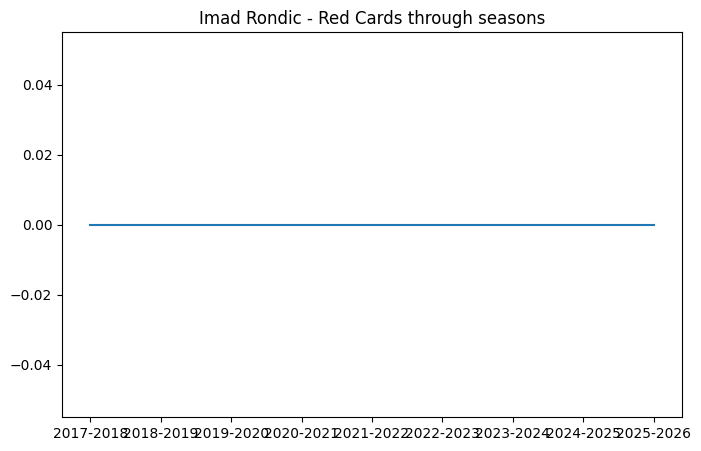

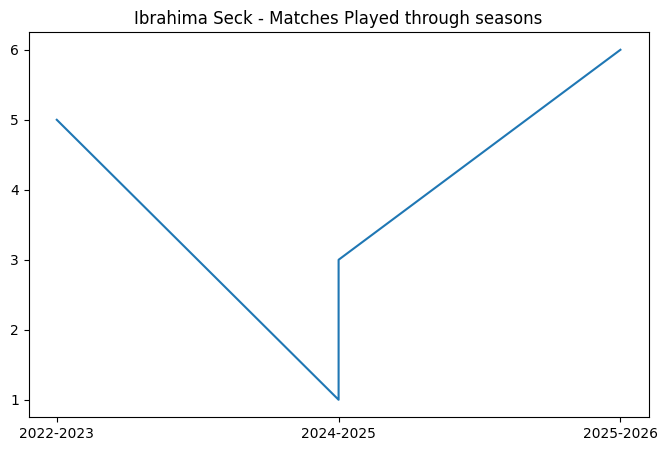

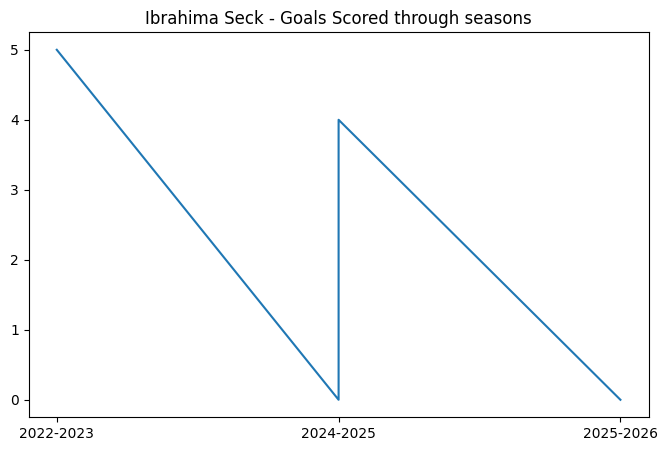

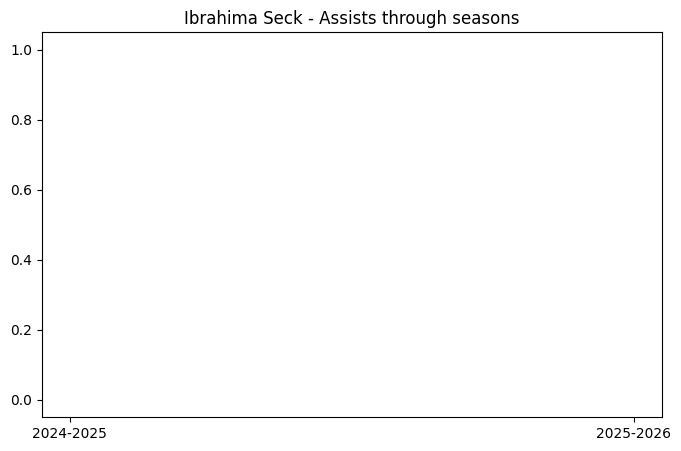

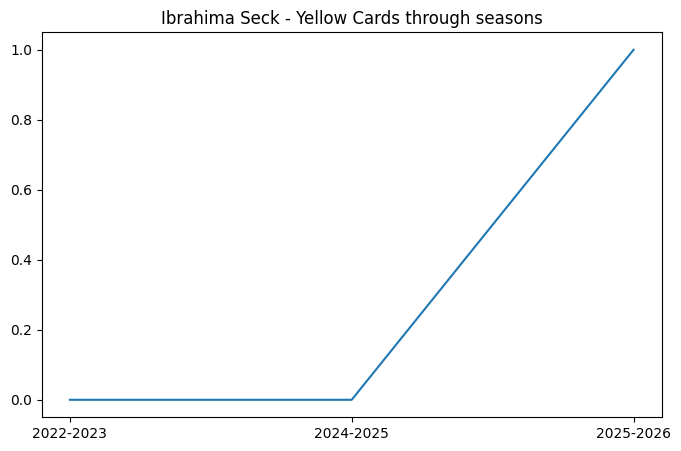

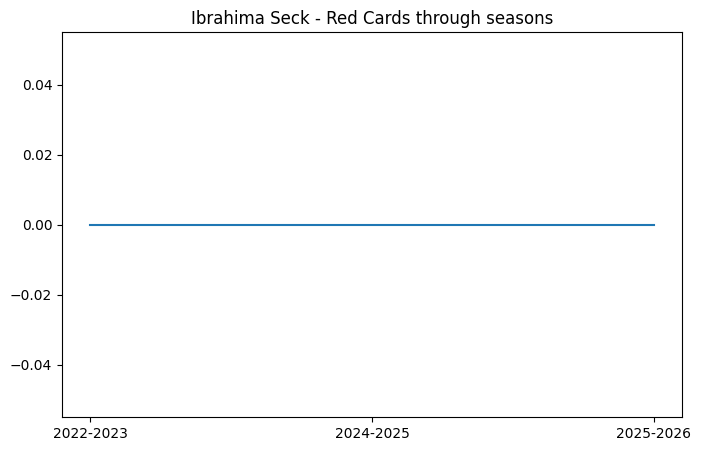

In [42]:

for player in squad:
    link = player['link']
    print(link)
    player_stats(link)
    